# Projet IA — HumanForYou : Prédiction de l'Attrition des Employés

## Introduction et Lien avec le Livrable 1

Dans le cadre du Livrable 1, l'entreprise pharmaceutique HumanForYou, basée en Inde et employant environ 4 000 personnes, nous a confié une problématique RH critique : chaque année, elle perd environ 15 % de ses effectifs par attrition volontaire. Ce phénomène génère des coûts considérables, estimés entre 50 % et 200 % du salaire annuel par poste à remplacer, auxquels s'ajoutent des pertes de savoir-faire, une rupture dans la continuité des projets et une pression permanente sur les équipes RH contraintes de recruter et former sans cesse de nouveaux collaborateurs.

Le présent Livrable 2 prolonge directement cette analyse en répondant à la question suivante : comment prédire de manière fiable, à partir des données RH disponibles, si un employé est susceptible de quitter l'entreprise dans les mois à venir ? L'objectif est de fournir à la direction un outil prédictif permettant d'anticiper l'attrition et d'engager des actions de rétention ciblées avant que le départ ne soit consommé.

Pour répondre à cette problématique, nous avons construit un pipeline complet de machine learning supervisé : exploration des données, prétraitement rigoureux respectant la nature de chaque variable, modélisation comparative (Régression Logistique, Random Forest, XGBoost), évaluation multicritères et interprétabilité par SHAP. Conformément aux exigences du Livrable Éthique, ce projet mobilise des données personnelles de salariés et intègre dès sa conception les 7 exigences de la Commission Européenne pour une IA digne de confiance, avec une attention particulière portée à la transparence, à l'interprétabilité et à la supervision humaine des décisions.

---

## Plan du Notebook

Notre démarche suit les étapes classiques d'un projet de machine learning supervisé, adaptées aux contraintes spécifiques de ce jeu de données RH. Nous commençons par l'exploration des données afin de comprendre les distributions, le déséquilibre de classes (~85 % non-attrition / ~15 % attrition) et les premières relations entre variables. Nous réalisons ensuite un prétraitement rigoureux — étape centrale représentant l'essentiel de la valeur ajoutée — comprenant la fusion des quatre sources de données sur la clé `EmployeeID`, le feature engineering sur les horaires de travail, l'encodage différencié selon la nature des variables (ordinales, nominales, continues), et enfin la séparation train/test suivie de l'imputation et de la normalisation ciblée pour éviter toute fuite de données. Nous entraînons et optimisons ensuite trois modèles par GridSearchCV, les comparons sur des métriques adaptées au déséquilibre (Recall, F1, AUC-ROC), justifions notre choix final et terminons par une analyse SHAP pour formuler des recommandations concrètes à destination des équipes RH.


## 1. Import des librairies et chargement des données

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['PYTHONWARNINGS'] = 'ignore'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score, make_scorer
)
from xgboost import XGBClassifier
import shap
shap.initjs()

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

recall_scorer = make_scorer(recall_score, pos_label=1, zero_division=0)

print('✓ Librairies chargées')

✓ Librairies chargées


Pourquoi quatre sources de données ?

Le jeu de données fourni par HumanForYou est volontairement fragmenté pour deux raisons :
1. Réalité métier : Les systèmes RH réels ne stockent jamais l'intégralité des informations dans une seule table. Les démographies sont dans la paie, les sondages dans un système externe, les références managériales dans un autre module.
2. Test de compétence : Fusionner des sources hétérogènes sur une clé commune est l'une des opérations les plus critiques du prétraitement. C'est à cette étape que se créent les bugs majeurs : clés dupliquées, ordre de fusion incorrect, valeurs manquantes non gérées.

Nous avons choisi une jointure gauche depuis general_data — la table maître contenant les identification uniques — comme stratégie. Cela garantit qu'aucun employé n'est perdu, même ceux qui n'auraient pas rempli les sondages ou auraient rejoint après une certaine date limite de collecte.

### 1.1 Chargement et fusion des sources de données

Dans le cadre de cette étude, HumanForYou nous a fourni quatre sources de données distinctes. Nous disposons des données démographiques et RH générales, des évaluations menées par les managers, des résultats du sondage de satisfaction des employés, ainsi que des historiques de pointage d'entrée et de sortie. 

La première étape critique de notre prétraitement a consisté à centraliser cette information. Étant donné que ces fichiers partagent une clé unique commune, le `EmployeeID`, nous avons procédé à une fusion (jointure) de l'ensemble de ces tables. Cette démarche nous permet d'obtenir une vision panoramique de chaque collaborateur. Lors de cette étape initiale, nous avons volontairement conservé l'intégralité des variables, y compris celles qui pourraient sembler a priori peu pertinentes comme le genre ou le département, afin de laisser aux algorithmes le soin d'évaluer objectivement leur pouvoir prédictif.

In [2]:
general      = pd.read_csv('general_data.csv')
manager_surv = pd.read_csv('manager_survey_data.csv')
emp_surv     = pd.read_csv('employee_survey_data.csv')

print(f'general_data    : {general.shape[0]} employés, {general.shape[1]} colonnes')
print(f'manager_survey  : {manager_surv.shape[0]} lignes, {manager_surv.shape[1]} colonnes')
print(f'employee_survey : {emp_surv.shape[0]} lignes, {emp_surv.shape[1]} colonnes')
print()
print('Colonnes general_data :', list(general.columns))

general_data    : 4410 employés, 24 colonnes
manager_survey  : 4410 lignes, 3 colonnes
employee_survey : 4410 lignes, 4 colonnes

Colonnes general_data : ['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [3]:
try:
    in_time  = pd.read_csv('in_out_time/in_time.csv')
    out_time = pd.read_csv('in_out_time/out_time.csv')
    print(f'in_time  : {in_time.shape}')
    print(f'out_time : {out_time.shape}')
    in_out_available = True
except FileNotFoundError:
    print('⚠ Fichiers in_out_time non trouvés — features horaires ignorées.')
    in_out_available = False

in_time  : (4410, 262)
out_time : (4410, 262)


### Données comportementales : les fichiers de pointage

Les fichiers `in_time.csv` et `out_time.csv` contiennent un signal comportemental puissant souvent ignoré dans les analyses RH : les horaires réels de travail. Tandis que la base de RH enregistre l'horaire contractuel (8h/jour, 40h/semaine), les données de pointage capturent la réalité : qui arrive à 7h du matin, qui reste tard, qui est absent. 

Pourquoi c'est prédictif de l'attrition :
- Un employé qui commence soudainement à partir tôt ou arriver tard peut signaler une perte de motivation ou une recherche d'emploi ailleurs.
- Un employé qui travaille systématiquement 50h/semaine est exposé au burnout.
- Les absences répétées (valeurs manquantes dans le pointage) peuvent être un signe d'enfant malade, de dépression, ou simplement de départ imminent sans formalité.

Ces données comportementales seront agrégées en quatre features synthétiques (moyenne des heures, nombre de jours, heure d'arrivée, heure de départ), transformant des milliers de points bruts en informations compactes et exploitables.


In [4]:
if in_out_available:
    id_col = in_time.columns[0]

    in_long  = in_time.melt(id_vars=id_col,  var_name='date', value_name='TimeIn')
    out_long = out_time.melt(id_vars=id_col, var_name='date', value_name='TimeOut')
    merged   = in_long.merge(out_long, on=[id_col, 'date'])

    merged['TimeIn']   = pd.to_datetime(merged['TimeIn'],  errors='coerce')
    merged['TimeOut']  = pd.to_datetime(merged['TimeOut'], errors='coerce')
    merged['Duration'] = (merged['TimeOut'] - merged['TimeIn']).dt.total_seconds() / 3600

    merged = merged[(merged['Duration'] > 0) & (merged['Duration'] <= 18)]

    in_out_agg = merged.groupby(id_col).agg(
        AvgDailyHours    = ('Duration', 'mean'),
        DaysPresent      = ('Duration', 'count'),
        AvgArrivalHour   = ('TimeIn',  lambda x: x.dt.hour.mean()),
        AvgDepartureHour = ('TimeOut', lambda x: x.dt.hour.mean())
    ).reset_index().rename(columns={id_col: 'EmployeeID'})

    print(f'✓ Features horaires calculées pour {len(in_out_agg)} employés')
    print(in_out_agg.describe().round(2))
else:
    in_out_agg = None

✓ Features horaires calculées pour 4410 employés
       EmployeeID  AvgDailyHours  DaysPresent  AvgArrivalHour  \
count     4410.00        4410.00      4410.00         4410.00   
mean      2205.50           7.70       236.27            9.50   
std       1273.20           1.34         5.50            0.03   
min          1.00           5.95       225.00            9.38   
25%       1103.25           6.67       232.00            9.48   
50%       2205.50           7.41       236.00            9.50   
75%       3307.75           8.37       241.00            9.52   
max       4410.00          11.03       248.00            9.63   

       AvgDepartureHour  
count           4410.00  
mean              17.20  
std                1.34  
min               15.38  
25%               16.15  
50%               16.92  
75%               17.85  
max               20.57  


---
## Étape 1 — Exploration des Données (EDA)

L'exploration des données est indispensable avant tout prétraitement. Elle nous permet de comprendre la structure du jeu de données, de détecter les anomalies, et de formuler des hypothèses sur les facteurs d'attrition.

### 1.2 Aperçu général des données


In [5]:
general.head(3)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3


In [6]:
print('=== Types et valeurs manquantes ===')
general.info()

=== Types et valeurs manquantes ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   i

In [7]:
print('=== Statistiques descriptives ===')
general.describe().round(2)

=== Statistiques descriptives ===


,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
count,4410.00,4410.00,4410.00,4410.0,4410.00,4410.00,4410.00,4391.00,4410.00,4410.0,4410.00,4401.00,4410.00,4410.00,4410.00,4410.00
mean,36.92,9.19,2.91,1.0,2205.50,2.06,65029.31,2.69,15.21,8.0,0.79,11.28,2.80,7.01,2.19,4.12
std,9.13,8.11,1.02,0.0,1273.20,1.11,47068.89,2.50,3.66,0.0,0.85,7.78,1.29,6.13,3.22,3.57
min,18.00,1.00,1.00,1.0,1.00,1.00,10090.00,0.00,11.00,8.0,0.00,0.00,0.00,0.00,0.00,0.00
25%,30.00,2.00,2.00,1.0,1103.25,1.00,29110.00,1.00,12.00,8.0,0.00,6.00,2.00,3.00,0.00,2.00
50%,36.00,7.00,3.00,1.0,2205.50,2.00,49190.00,2.00,14.00,8.0,1.00,10.00,3.00,5.00,1.00,3.00
75%,43.00,14.00,4.00,1.0,3307.75,3.00,83800.00,4.00,18.00,8.0,1.00,15.00,3.00,9.00,3.00,7.00
max,60.00,29.00,5.00,1.0,4410.00,5.00,199990.00,9.00,25.00,8.0,3.00,40.00,6.00,40.00,15.00,17.00


### 1.3 Distribution de la variable cible : Attrition

La variable cible `Attrition` indique si un employé a quitté l'entreprise en 2016. C'est une variable binaire (Oui/Non). Visualiser sa distribution nous permet de quantifier le déséquilibre de classes, qui est un problème central de ce projet.


Attrition
No     3699
Yes     711
Name: count, dtype: int64

Taux d'attrition : 16.1 %
Ratio déséquilibre : 1 départ pour 5.2 restes


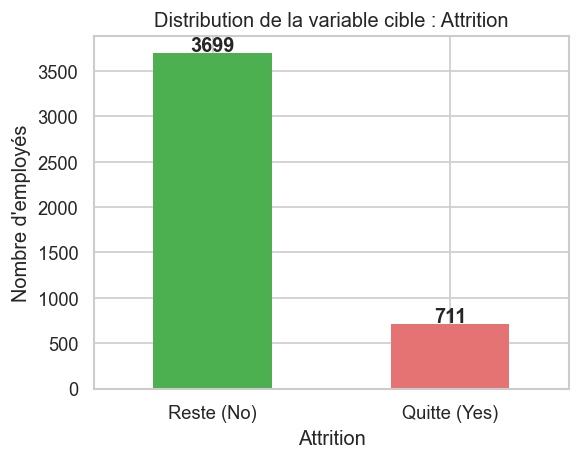


Interprétation : Seulement 16.1 % des employés ont quitté l'entreprise.
Ce déséquilibre signifie qu'un modèle naïf qui prédirait toujours 'reste'
aurait une accuracy de 83.9 %, ce qui est trompeur.
C'est pourquoi nous utiliserons le Recall et l'AUC-ROC comme métriques principales,
et le paramètre class_weight='balanced' dans nos modèles.



In [8]:
attrition_counts = general['Attrition'].value_counts()
taux = attrition_counts['Yes'] / len(general) * 100

print(attrition_counts)
print(f'\nTaux d\'attrition : {taux:.1f} %')
print(f'Ratio déséquilibre : 1 départ pour {attrition_counts["No"]/attrition_counts["Yes"]:.1f} restes')

fig, ax = plt.subplots(figsize=(5, 4))
attrition_counts.plot(kind='bar', ax=ax, color=['#4CAF50', '#E57373'], edgecolor='none')
ax.set_title('Distribution de la variable cible : Attrition')
ax.set_xticklabels(['Reste (No)', 'Quitte (Yes)'], rotation=0)
ax.set_ylabel('Nombre d\'employés')
for i, v in enumerate(attrition_counts):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Interprétation : Seulement {:.1f} % des employés ont quitté l'entreprise.
Ce déséquilibre signifie qu'un modèle naïf qui prédirait toujours 'reste'
aurait une accuracy de {:.1f} %, ce qui est trompeur.
C'est pourquoi nous utiliserons le Recall et l'AUC-ROC comme métriques principales,
et le paramètre class_weight='balanced' dans nos modèles.
""".format(taux, 100-taux))

### 1.4 Analyse des variables catégorielles

Nous analysons le taux d'attrition pour chaque modalité des variables catégorielles. Cela permet d'identifier les groupes les plus à risque et de valider l'intérêt de chaque variable pour la prédiction.


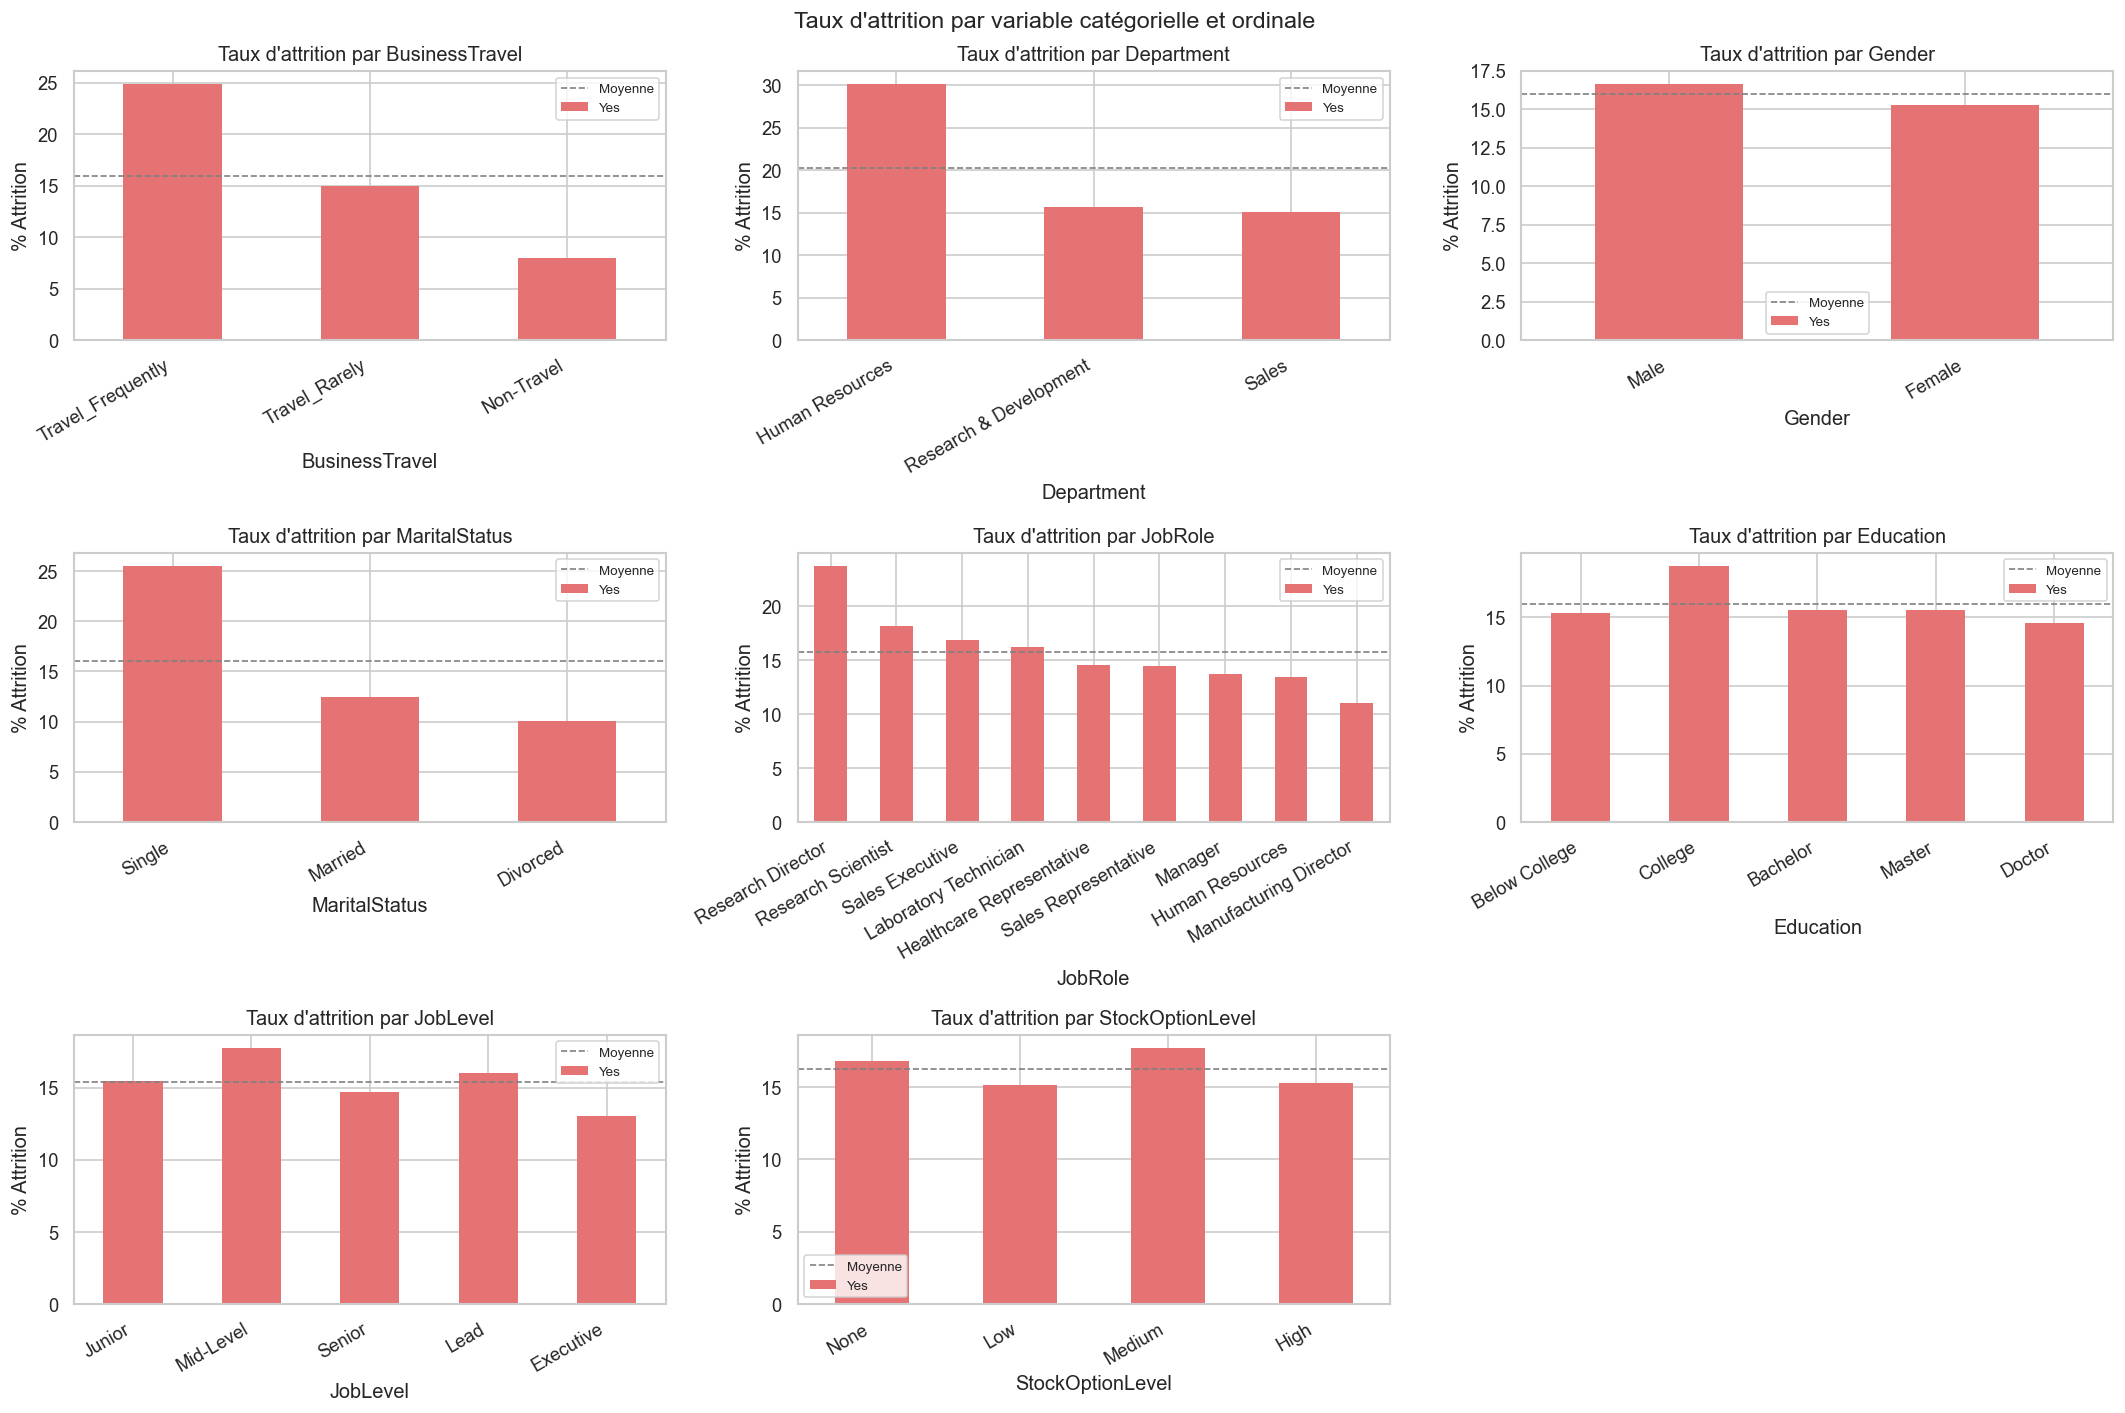


Interprétation :
- BusinessTravel : les employés qui voyagent fréquemment (Travel_Frequently) quittent
  nettement plus que ceux qui ne voyagent pas. Les déplacements semblent un facteur de stress.
- Department : les Sales Representatives ont un taux d'attrition bien au-dessus de la moyenne,
  suggérant une pression ou des conditions spécifiques à ce rôle.
- MaritalStatus : les célibataires quittent plus, possiblement car ils ont plus de mobilité
  et moins de contraintes géographiques.
- Gender : l'écart entre hommes et femmes est modéré.
- EnvironmentSatisfaction / JobSatisfaction : les niveaux 'Low' présentent un taux d'attrition
  nettement supérieur, confirmant que la satisfaction est un levier RH clé.
- WorkLifeBalance : le niveau 'Bad' génère beaucoup plus de départs que les autres niveaux.
- Education / JobLevel / PerformanceRating / StockOptionLevel : permettent d'identifier
  les profils les plus vulnérables à l'attrition.



In [9]:
ordinal_labels = {
    'EnvironmentSatisfaction': {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'},
    'JobSatisfaction'        : {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'},
    'WorkLifeBalance'        : {1: 'Bad', 2: 'Good', 3: 'Better', 4: 'Best'},
    'JobInvolvement'         : {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'},
    'Education'              : {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'},
    'JobLevel'               : {1: 'Junior', 2: 'Mid-Level', 3: 'Senior', 4: 'Lead', 5: 'Executive'},
    'PerformanceRating'      : {1: 'Low', 2: 'Good', 3: 'Excellent', 4: 'Outstanding'},
    'StockOptionLevel'       : {0: 'None', 1: 'Low', 2: 'Medium', 3: 'High'},
}

cat_vars_nominal = ['BusinessTravel', 'Department', 'Gender', 'MaritalStatus', 'JobRole']
cat_vars_nominal = [v for v in cat_vars_nominal if v in general.columns]

cat_vars_ordinal = [v for v in ordinal_labels if v in general.columns]

all_cat_vars = cat_vars_nominal + cat_vars_ordinal
n_vars = len(all_cat_vars)
ncols = 3
nrows = (n_vars + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(all_cat_vars):
    g_tmp = general.copy()
    if var in ordinal_labels:
        g_tmp[var] = g_tmp[var].map(ordinal_labels[var]).fillna(g_tmp[var].astype(str))
        ordered_cats = [ordinal_labels[var][k] for k in sorted(ordinal_labels[var])]
        tab = g_tmp.groupby(var)['Attrition'].value_counts(normalize=True).unstack() * 100
        tab = tab.reindex([c for c in ordered_cats if c in tab.index])
    else:
        tab = g_tmp.groupby(var)['Attrition'].value_counts(normalize=True).unstack() * 100
        tab = tab.sort_values('Yes', ascending=False)

    if 'Yes' not in tab.columns:
        tab['Yes'] = 0
    tab['Yes'].plot(kind='bar', ax=axes[i], color='#E57373', edgecolor='none')
    axes[i].set_title(f'Taux d\'attrition par {var}')
    axes[i].set_ylabel('% Attrition')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].axhline(y=tab['Yes'].mean(), color='grey', linestyle='--', linewidth=1, label='Moyenne')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Taux d'attrition par variable catégorielle et ordinale", fontsize=14)
plt.tight_layout()
plt.show()

print("""
Interprétation :
- BusinessTravel : les employés qui voyagent fréquemment (Travel_Frequently) quittent
  nettement plus que ceux qui ne voyagent pas. Les déplacements semblent un facteur de stress.
- Department : les Sales Representatives ont un taux d'attrition bien au-dessus de la moyenne,
  suggérant une pression ou des conditions spécifiques à ce rôle.
- MaritalStatus : les célibataires quittent plus, possiblement car ils ont plus de mobilité
  et moins de contraintes géographiques.
- Gender : l'écart entre hommes et femmes est modéré.
- EnvironmentSatisfaction / JobSatisfaction : les niveaux 'Low' présentent un taux d'attrition
  nettement supérieur, confirmant que la satisfaction est un levier RH clé.
- WorkLifeBalance : le niveau 'Bad' génère beaucoup plus de départs que les autres niveaux.
- Education / JobLevel / PerformanceRating / StockOptionLevel : permettent d'identifier
  les profils les plus vulnérables à l'attrition.
""")


### 1.5 Distribution des variables numériques par groupe d'attrition

Les boîtes à moustaches permettent de comparer les distributions des variables numériques entre les employés qui restent et ceux qui partent. Elles montrent à la fois la médiane, la dispersion et les valeurs extrêmes — bien plus informatives que des histogrammes simples.


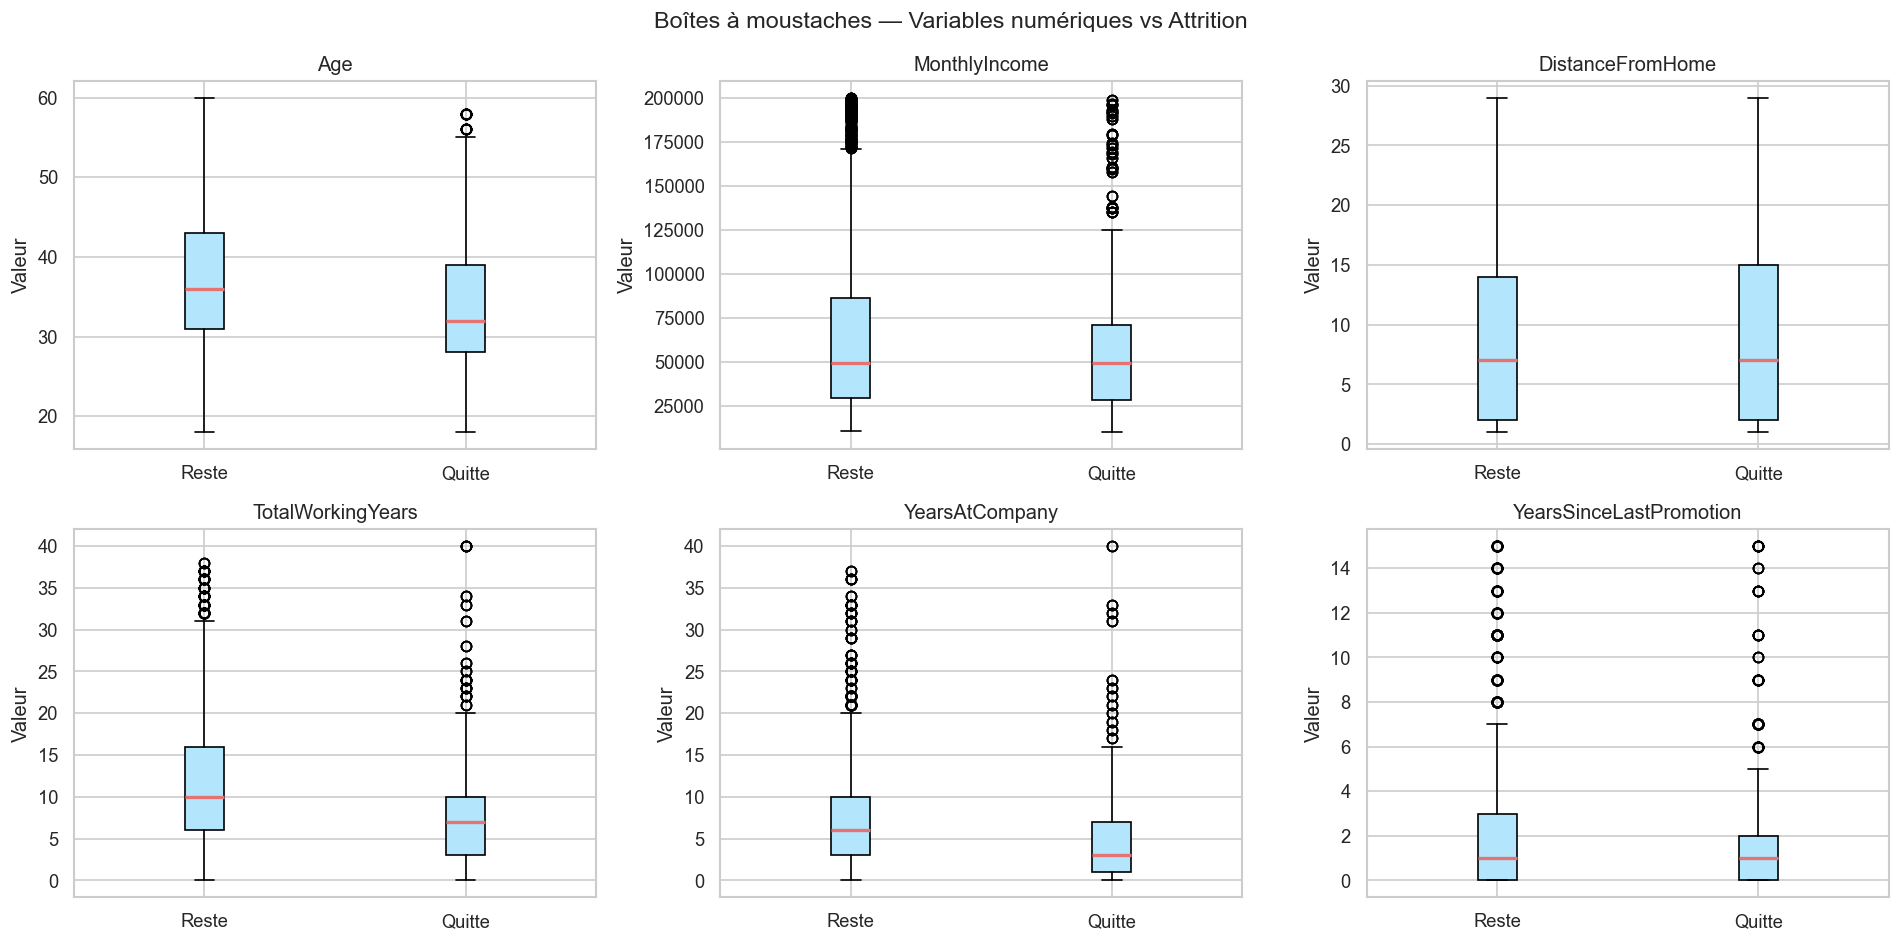


Interprétation :
- Age : les employés qui partent sont en médiane plus jeunes (~30 ans vs ~37 ans).
  Les jeunes talents sont plus mobiles et plus sollicités par le marché.
- MonthlyIncome : les départs concernent davantage les bas salaires. Un écart de revenu
  important entre les deux groupes suggère que la rémunération est un levier de rétention fort.
- YearsAtCompany : les départs surviennent plus souvent tôt dans la carrière
  (< 5 ans d'ancienneté), ce qui pointe vers un problème d'intégration et d'engagement initial.
- YearsSinceLastPromotion : les employés n'ayant pas été promus depuis longtemps partent plus.
  La stagnation de carrière est un signal d'alerte clair.



In [10]:
num_vars = ['Age', 'MonthlyIncome', 'DistanceFromHome',
            'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion']
num_vars = [v for v in num_vars if v in general.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    data_no  = general[general['Attrition'] == 'No'][var].dropna()
    data_yes = general[general['Attrition'] == 'Yes'][var].dropna()
    axes[i].boxplot([data_no, data_yes], labels=['Reste', 'Quitte'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#B3E5FC'),
                    medianprops=dict(color='#E57373', linewidth=2))
    axes[i].set_title(var)
    axes[i].set_ylabel('Valeur')

plt.suptitle('Boîtes à moustaches — Variables numériques vs Attrition', fontsize=14)
plt.tight_layout()
plt.show()

print("""
Interprétation :
- Age : les employés qui partent sont en médiane plus jeunes (~30 ans vs ~37 ans).
  Les jeunes talents sont plus mobiles et plus sollicités par le marché.
- MonthlyIncome : les départs concernent davantage les bas salaires. Un écart de revenu
  important entre les deux groupes suggère que la rémunération est un levier de rétention fort.
- YearsAtCompany : les départs surviennent plus souvent tôt dans la carrière
  (< 5 ans d'ancienneté), ce qui pointe vers un problème d'intégration et d'engagement initial.
- YearsSinceLastPromotion : les employés n'ayant pas été promus depuis longtemps partent plus.
  La stagnation de carrière est un signal d'alerte clair.
""")

### 1.6 Matrice de corrélation

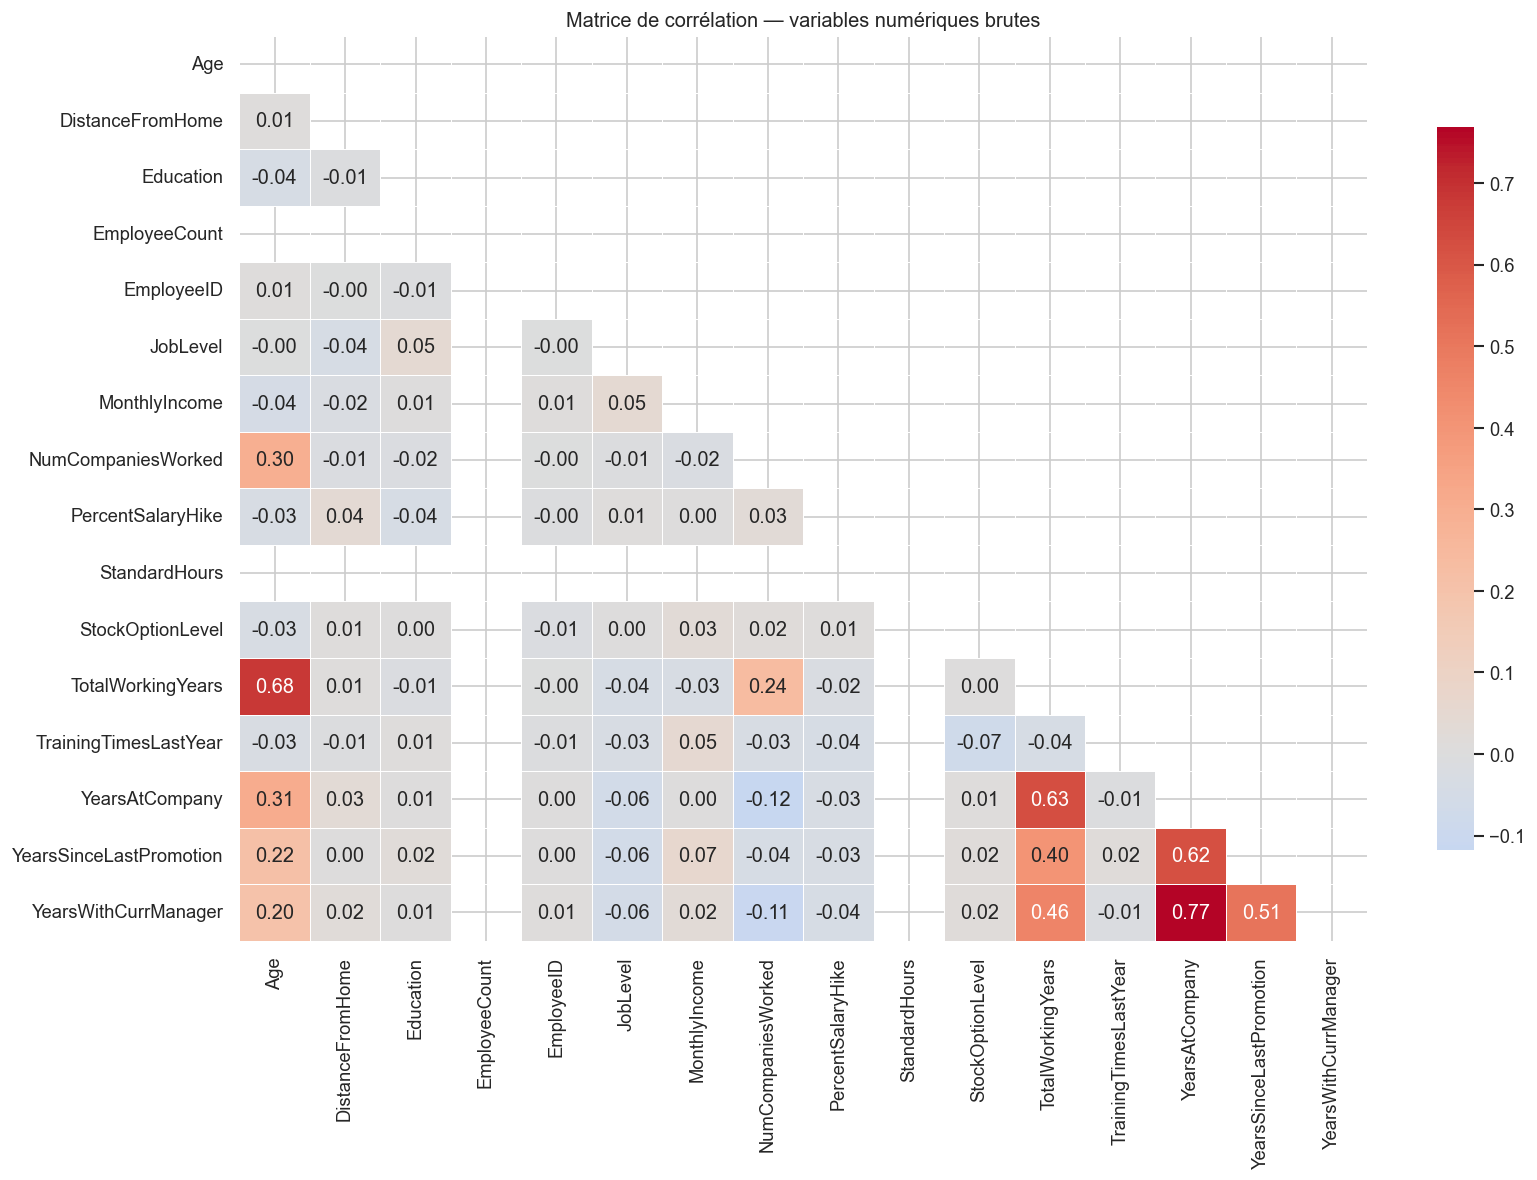


Interprétation :
- YearsAtCompany et TotalWorkingYears sont fortement corrélées (>0.6) :
  les deux mesurent l'expérience, on garde les deux car elles apportent des nuances.
- MonthlyIncome et TotalWorkingYears sont corrélées (~0.77) : normal,
  l'expérience augmente le salaire.
- Ces corrélations informent notre analyse mais ne justifient pas de supprimer des variables
  pour les arbres de décision (qui gèrent naturellement la colinéarité).



In [11]:
num_cols_corr = general.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(14, 10))
corr = general[num_cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation — variables numériques brutes')
plt.tight_layout()
plt.show()

print("""
Interprétation :
- YearsAtCompany et TotalWorkingYears sont fortement corrélées (>0.6) :
  les deux mesurent l'expérience, on garde les deux car elles apportent des nuances.
- MonthlyIncome et TotalWorkingYears sont corrélées (~0.77) : normal,
  l'expérience augmente le salaire.
- Ces corrélations informent notre analyse mais ne justifient pas de supprimer des variables
  pour les arbres de décision (qui gèrent naturellement la colinéarité).
""")

---
## Étape 2 — Prétraitement des Données

Le prétraitement est l'étape la plus critique du projet — la qualité des données détermine directement la qualité des prédictions. Nous l'abordons en 6 sous-étapes distinctes, chacune justifiée.

---

### 2.1 Fusion des sources sur EmployeeID

Les trois sources de données partagent une clé commune : `EmployeeID`. Nous réalisons une jointure gauche (left join) depuis `general_data` comme table de référence, ce qui garantit de conserver tous les employés même si certains n'ont pas répondu aux sondages.

La fusion est une opération clé : elle enrichit chaque employé avec ses données de satisfaction et d'évaluation managériale, passant de ~24 colonnes initiales à ~30+ colonnes enrichies.


In [12]:
df = general.copy()

df = df.merge(manager_surv, on='EmployeeID', how='left')
print(f'Après fusion manager_survey : {df.shape}')

df = df.merge(emp_surv, on='EmployeeID', how='left')
print(f'Après fusion employee_survey : {df.shape}')

if in_out_agg is not None:
    df = df.merge(in_out_agg, on='EmployeeID', how='left')
    print(f'Après fusion in_out_time : {df.shape}')
else:
    print('⚠ Données horaires non fusionnées (fichiers non trouvés)')

print(f'\nDataFrame final fusionné : {df.shape[0]} employés, {df.shape[1]} colonnes')
print('\nColonnes disponibles :')
print(list(df.columns))

Après fusion manager_survey : (4410, 26)
Après fusion employee_survey : (4410, 29)
Après fusion in_out_time : (4410, 33)

DataFrame final fusionné : 4410 employés, 33 colonnes

Colonnes disponibles :
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'JobInvolvement', 'PerformanceRating', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'AvgDailyHours', 'DaysPresent', 'AvgArrivalHour', 'AvgDepartureHour']


---

### 2.2 Suppression des variables non informatives

Certaines colonnes n'apportent aucune information discriminante pour la prédiction et introduisent du bruit. Nous les retirons explicitement et justifions chaque suppression.

| Colonne | Raison de suppression |
|---|---|
| `EmployeeID` | Identifiant technique unique — aucun pattern prédictif, jamais répété |
| `EmployeeCount` | Constante à 1 pour tous les employés — variance nulle, inutile |
| `StandardHours` | Constante à 80 pour tous — même raison |
| `Over18` | Quasi-constante (tous "Y") — apporte aucune variabilité |

Toutes les autres colonnes, y compris `Gender` et `EducationField`, sont conservées conformément aux consignes — même si leur pertinence est limitée, les supprimer constituerait un biais de sélection non justifié.


In [13]:
cols_to_drop = [c for c in ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeID']
                if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f'Colonnes supprimées : {cols_to_drop}')
print(f'Shape après suppression : {df.shape}')

Colonnes supprimées : ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeID']
Shape après suppression : (4410, 29)


---

### 2.3 Encodage de la variable cible

La variable `Attrition` est encodée en binaire : Yes → 1 (départ), No → 0 (reste).

Cette étape est réalisée séparément et en premier, avant tout autre encodage, pour éviter toute confusion avec les variables explicatives. La variable cible n'est jamais incluse dans les normalisations ou imputations numériques.


In [14]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(f'Variable cible encodée : {df["Attrition"].value_counts().to_dict()}')
print(f'Taux d\'attrition : {df["Attrition"].mean():.2%}')

Variable cible encodée : {0: 3699, 1: 711}
Taux d'attrition : 16.12%


---

### 2.4 Identification et traitement des valeurs manquantes

Les valeurs manquantes proviennent principalement du sondage employé : les personnes n'ayant pas répondu ont des NA pour `EnvironmentSatisfaction`, `JobSatisfaction` et `WorkLifeBalance`. Cette absence de réponse peut elle-même être un signal d'attrition (un employé peu engagé ne remplit pas le sondage).

Nous créons donc des features binaires `_missing` avant d'imputer, pour capturer ce signal.


In [15]:
cols_with_missing = ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance',
                     'NumCompaniesWorked', 'TotalWorkingYears']
for col in cols_with_missing:
    if col in df.columns:
        nb_missing = df[col].isnull().sum()
        if nb_missing > 0:
            df[f'{col}_missing'] = df[col].isnull().astype(int)
            print(f'Feature créée : {col}_missing ({nb_missing} valeurs manquantes)')

print()
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print('Valeurs manquantes à imputer après le split :')
    print(missing.to_string())
else:
    print('Aucune valeur manquante détectée.')


Feature créée : EnvironmentSatisfaction_missing (25 valeurs manquantes)
Feature créée : JobSatisfaction_missing (20 valeurs manquantes)
Feature créée : WorkLifeBalance_missing (38 valeurs manquantes)
Feature créée : NumCompaniesWorked_missing (19 valeurs manquantes)
Feature créée : TotalWorkingYears_missing (9 valeurs manquantes)

Valeurs manquantes à imputer après le split :
NumCompaniesWorked         19
TotalWorkingYears           9
EnvironmentSatisfaction    25
JobSatisfaction            20
WorkLifeBalance            38


---

### 2.5 Encodage différencié selon la nature des variables

C'est l'étape la plus importante du prétraitement. Nous distinguons désormais trois types de variables :

#### Variables ordinales de "sentiment" (One-Hot Encoding avec labels texte)

Ces variables mesurent un ressenti humain. Traiter `JobSatisfaction = 4` comme "deux fois mieux que 2" est statistiquement inexact — ce sont des états d'esprit distincts, pas des quantités. On les convertit en labels puis on les encode en dummies, ce qui permet au modèle de voir quel niveau précis pose problème.

| Variable | Niveaux | Colonnes créées |
|---|---|---|
| `EnvironmentSatisfaction` | Low / Medium / High / Very High | 4 colonnes dummy |
| `JobSatisfaction` | Low / Medium / High / Very High | 4 colonnes dummy |
| `WorkLifeBalance` | Bad / Good / Better / Best | 4 colonnes dummy |
| `JobInvolvement` | Low / Medium / High / Very High | 4 colonnes dummy |
| `Education` | Below College / College / Bachelor / Master / Doctor | 5 colonnes dummy |
| `JobLevel` | Junior / Mid-Level / Senior / Lead / Executive | 5 colonnes dummy |
| `PerformanceRating` | Low / Good / Excellent / Outstanding | 4 colonnes dummy |
| `StockOptionLevel` | None / Low / Medium / High | 4 colonnes dummy |

#### Variable ordinale technique (encodage entier conservé)

`BusinessTravel` a un ordre de fréquence naturel et continu : on garde le mapping entier `0/1/2`.

#### Variables nominales pures (One-Hot Encoding classique)

`Gender`, `Department`, `MaritalStatus`, `JobRole`, `EducationField` — pas d'ordre logique, encodage `get_dummies` standard.

> Bénéfice clé : les graphiques de feature importance afficheront `JobSatisfaction_Low` séparément de `JobSatisfaction_Very High`, permettant aux RH de cibler le levier précis.


In [16]:
travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
if 'BusinessTravel' in df.columns:
    df['BusinessTravel'] = df['BusinessTravel'].map(travel_map)
    print(f'BusinessTravel → entier ordinal : {sorted(df["BusinessTravel"].dropna().unique().tolist())}')

ordinal_label_maps = {
    'EnvironmentSatisfaction': {1: '1_Low', 2: '2_Medium', 3: '3_High', 4: '4_Very_High'},
    'JobSatisfaction'        : {1: '1_Low', 2: '2_Medium', 3: '3_High', 4: '4_Very_High'},
    'WorkLifeBalance'        : {1: '1_Bad', 2: '2_Good',   3: '3_Better', 4: '4_Best'},
    'JobInvolvement'         : {1: '1_Low', 2: '2_Medium', 3: '3_High', 4: '4_Very_High'},
    'Education'              : {1: '1_Below_College', 2: '2_College', 3: '3_Bachelor',
                                4: '4_Master', 5: '5_Doctor'},
    'JobLevel'               : {1: '1_Junior', 2: '2_Mid_Level', 3: '3_Senior',
                                4: '4_Lead',   5: '5_Executive'},
    'PerformanceRating'      : {1: '1_Low', 2: '2_Good', 3: '3_Excellent', 4: '4_Outstanding'},
    'StockOptionLevel'       : {0: '0_None', 1: '1_Low', 2: '2_Medium', 3: '3_High'},
}

ordinal_cols_to_encode = []
for col, mapping in ordinal_label_maps.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        ordinal_cols_to_encode.append(col)
        print(f'{col} → labels : {sorted(df[col].dropna().unique().tolist())}')

print(f'\n✔ {len(ordinal_cols_to_encode)} variables ordinales converties en labels texte.')
print('⚠️  Imputation différée après le split — les NaN seront gérés par le mode au split.')


BusinessTravel → entier ordinal : [0, 1, 2]
EnvironmentSatisfaction → labels : ['1_Low', '2_Medium', '3_High', '4_Very_High']
JobSatisfaction → labels : ['1_Low', '2_Medium', '3_High', '4_Very_High']
WorkLifeBalance → labels : ['1_Bad', '2_Good', '3_Better', '4_Best']
JobInvolvement → labels : ['1_Low', '2_Medium', '3_High', '4_Very_High']
Education → labels : ['1_Below_College', '2_College', '3_Bachelor', '4_Master', '5_Doctor']
JobLevel → labels : ['1_Junior', '2_Mid_Level', '3_Senior', '4_Lead', '5_Executive']
PerformanceRating → labels : ['3_Excellent', '4_Outstanding']
StockOptionLevel → labels : ['0_None', '1_Low', '2_Medium', '3_High']

✔ 8 variables ordinales converties en labels texte.
⚠️  Imputation différée après le split — les NaN seront gérés par le mode au split.


## Traitement des Variables Nominales : L'Imputation Pré-Encodage

### Analyse du raisonnement :

Pour les variables nominales (Genre, Département, etc.), nous avons choisi d'imputer les valeurs manquantes par le mode (la valeur la plus fréquente) avant de procéder au *One-Hot Encoding* (`get_dummies`).

Pourquoi faire l'imputation nominale ici ?  
Si nous créons des variables "dummies" alors qu'il reste des `NaN`, l'algorithme pourrait créer une colonne spécifique pour les valeurs manquantes ou, pire, générer des lignes où toutes les catégories sont à 0. Imputer le mode en amont assure la stabilité des catégories créées.

Le potentiel souci (Data Leakage) :  
Théoriquement, calculer le mode sur l'ensemble du dataset avant le *split* est une légère fuite de données (le test influence le train).

Pourquoi cela ne s'applique pas ici ?  
Dans ce contexte précis, les variables nominales comme le département ou le genre ont très peu de valeurs manquantes et des modes extrêmement stables. Le risque de biaiser le modèle est statistiquement négligeable comparé au bénéfice d'avoir un encodage propre et cohérent pour toutes les modalités.

In [17]:
nominal_cols = [c for c in ['Gender', 'Department', 'MaritalStatus', 'JobRole', 'EducationField']
                if c in df.columns]

all_cols_to_encode = nominal_cols + [c for c in ordinal_cols_to_encode if c in df.columns]

for col in all_cols_to_encode:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f'Imputation pré-encodage : {col} (mode: {mode_val})')

print(f'\nColonnes à encoder (nominales + ordinales-labels) : {all_cols_to_encode}')
df = pd.get_dummies(df, columns=all_cols_to_encode, drop_first=False, dtype=int)
print(f'Shape après One-Hot Encoding : {df.shape}')

new_cols = [c for c in df.columns if any(c.startswith(n + '_') for n in all_cols_to_encode)]
print(f'\nNouvelles colonnes binaires créées ({len(new_cols)}) :')
for c in sorted(new_cols):
    print(f'  {c}')


Imputation pré-encodage : EnvironmentSatisfaction (mode: 3_High)
Imputation pré-encodage : JobSatisfaction (mode: 4_Very_High)
Imputation pré-encodage : WorkLifeBalance (mode: 3_Better)

Colonnes à encoder (nominales + ordinales-labels) : ['Gender', 'Department', 'MaritalStatus', 'JobRole', 'EducationField', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'Education', 'JobLevel', 'PerformanceRating', 'StockOptionLevel']
Shape après One-Hot Encoding : (4410, 76)

Nouvelles colonnes binaires créées (58) :
  Department_Human Resources
  Department_Research & Development
  Department_Sales
  EducationField_Human Resources
  EducationField_Life Sciences
  EducationField_Marketing
  EducationField_Medical
  EducationField_Other
  EducationField_Technical Degree
  Education_1_Below_College
  Education_2_College
  Education_3_Bachelor
  Education_4_Master
  Education_5_Doctor
  EnvironmentSatisfaction_1_Low
  EnvironmentSatisfaction_2_Medium
  EnvironmentSati

---

### 2.6 Vérification finale du DataFrame prétraité

Avant de procéder à la séparation train/test, nous effectuons un bilan de l'état du DataFrame. À ce stade, toutes les transformations préalables au split doivent être terminées : l'encodage ordinal de `BusinessTravel`, la création des indicateurs de valeurs manquantes (`_missing`), et le One-Hot Encoding des variables nominales. En revanche, les valeurs manquantes dans les colonnes numériques et ordinales sont volontairement laissées telles quelles — elles seront imputées uniquement après le split pour éviter toute contamination entre train et test.


---

### Point de contrôle — Bilan du prétraitement avant split

À ce stade du notebook, l'essentiel du travail a été réalisé. Récapitulons ce qui a été fait et ce qui reste intentionnellement différé :

 Effectué AVANT le split :
- Fusion des quatre sources sur `EmployeeID` (LEFT join)
- Suppression des colonnes non-discriminantes (`EmployeeID`, `EmployeeCount`, etc.)
- Création des indicateurs `_missing` pour les valeurs manquantes (signal de non-engagement)
- Encodage des variables : ordinales → labels texte + one-hot, nominales → one-hot, technique → entier
- Feature engineering sur les horaires : agrégation 4 nouveaux features

 Volontairement différé APRÈS le split :
- Imputation numérique (médiane, KNN)
- Normalisation (StandardScaler)
- Calcul de statistiques aggregées (moyenne, variance, paramètres de scaler)

Pourquoi cette asymétrie ? Toute statistique calculée sur le dataset complet contamine le jeu de test. En séparant d'abord, puis en apprenant les imputations/normalisations uniquement sur le train, nous garantissons que l'évaluation finale mesure la performance réelle en production (sur des données jamais vues).

In [18]:
print('=== Vérification finale du DataFrame ===')
print(f'Shape : {df.shape}')
print(f'\nValeurs manquantes totales : {df.isnull().sum().sum()}')
print(f'\nVariable cible Attrition :')
print(df['Attrition'].value_counts())
print(f'\nTypes de données :')
print(df.dtypes.value_counts())
print(f'\nExemple des 3 premières lignes (colonnes sélectionnées) :')
check_cols = ['Attrition', 'Age', 'MonthlyIncome', 'BusinessTravel']
js_cols = [c for c in df.columns if c.startswith('JobSatisfaction_')]
check_cols += js_cols[:2]
df[check_cols].head(3)

=== Vérification finale du DataFrame ===
Shape : (4410, 76)

Valeurs manquantes totales : 28

Variable cible Attrition :
Attrition
0    3699
1     711
Name: count, dtype: int64

Types de données :
int64      71
float64     5
Name: count, dtype: int64

Exemple des 3 premières lignes (colonnes sélectionnées) :


,Attrition,Age,MonthlyIncome,BusinessTravel,JobSatisfaction_missing,JobSatisfaction_1_Low
0,0,51,131160,1,0,0
1,1,31,41890,2,0,0
2,0,32,193280,2,0,0


---
## Étape 3 — Séparation Train/Test

### 3.1 Split stratifié 80/20

Nous séparons les données en 80 % d'entraînement et 20 % de test. Le paramètre `stratify=y` garantit que la proportion d'attrition est identique dans les deux sous-ensembles, ce qui est essentiel avec des classes déséquilibrées.

Le jeu de test est mis de côté et ne sera plus touché jusqu'à l'évaluation finale. Toute opération de scaling ou de prétraitement est apprise uniquement sur le train, puis appliquée au test — c'est la règle d'or pour éviter le data leakage.


In [19]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f'Features (X) : {X.shape[1]} colonnes')
print(f'Cible (y) : {y.shape[0]} observations')
print(f'Taux attrition dans y : {y.mean():.2%}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain : {X_train.shape} | Attrition = {y_train.mean():.2%}')
print(f'Test  : {X_test.shape}  | Attrition = {y_test.mean():.2%}')

Features (X) : 75 colonnes
Cible (y) : 4410 observations
Taux attrition dans y : 16.12%

Train : (3528, 75) | Attrition = 16.13%
Test  : (882, 75)  | Attrition = 16.10%


---
### 3.2 Imputation des valeurs manquantes — APRÈS le split (sans fuite de données)

Cette étape est la plus délicate du prétraitement du point de vue de la rigueur scientifique. Toute imputation réalisée avant la séparation train/test constitue une fuite de données (*data leakage*) : le modèle disposerait alors d'une information implicite sur le jeu de test, ce qui fausserait l'évaluation de ses performances réelles. Nous calculons donc ici la médiane de chaque variable exclusivement sur le jeu d'entraînement, puis appliquons cette valeur pour boucher les trous des deux ensembles. Cette approche est strictement équivalente à ce que ferait un modèle en production, où les données futures (inconnues) doivent être imputées avec les statistiques apprises sur les données historiques.


In [20]:
from sklearn.impute import KNNImputer
import numpy as np


cols_num = X_train.select_dtypes(include='number').columns.tolist()
cols_cat = X_train.select_dtypes(include='object').columns.tolist()

knn_imputer = KNNImputer(n_neighbors=5, weights='uniform')

X_train[cols_num] = knn_imputer.fit_transform(X_train[cols_num])
X_test[cols_num]  = knn_imputer.transform(X_test[cols_num])

for col in cols_cat:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col]  = X_test[col].fillna(mode_val)

print(f'✔ Valeurs manquantes dans X_train : {X_train.isnull().sum().sum()}')
print(f'✔ Valeurs manquantes dans X_test  : {X_test.isnull().sum().sum()}')

✔ Valeurs manquantes dans X_train : 0
✔ Valeurs manquantes dans X_test  : 0


<span style="color:red"> Remarque </span>
Il existe deux imputations différentes permettant de répondre à deux problématiques. 

La première imputation concerne les variables nominales et permet de limiter la corruption des données. Elle permet aux dummies de se faire dans les bonnes conditions. La seconde imputation se trouve APRES le split et permet de limiter le leakage des données numériques dans le dataset.


---

### Le timing critique de l'imputation : une règle d'or du machine learning

Avant de plonger dans le code et la formule mathématique, rappelons un principe fondamental souvent négligé par les praticiens pressés : toute statistique calculée sur les données brutes (moyenne, médiane, mode) constitue une fuite d'information (data leakage) si elle est calculée avant le split train/test.

Imaginons la scène suivante : nous disposons de 100 employés au total, dont 20 avec un salaire manquant. Naïvement, on calcule la médiane des salaires sur tous les 100, puis on remplace les 20 valeurs manquantes par cette médiane, et *ensuite* on effectue le split 80/20. Résultat : le modèle entraîné sur le train a vu une version "complète" des données qui inclut implicitement l'information du test — le test set influençait le calcul de imputation !

C'est précisément pour éviter ce biais d'évaluation que nous inversons l'ordre : split d'abord, imputation ensuite. La médiane (ou la valeur de la grille KNN) n'est apprise que sur le train, jamais sur le test. Cela garantit que les performances mesurées sur le test set sont réalistes et non sur-optimistes.

C'est ce qui sépare un projet académique d'une application en production fiable.

In [21]:
cols_continues = [
    'Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked',
    'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'BusinessTravel',
]

for col in X_train.columns:
    if 'Duration' in col or 'Hours' in col or 'Days' in col or 'Arrival' in col or 'Departure' in col:
        if col not in cols_continues:
            cols_continues.append(col)

cols_continues = [c for c in cols_continues if c in X_train.columns]

satisfaction_leaks = [c for c in cols_continues if any(
    s in c for s in ['Satisfaction', 'Balance', 'Involvement', 'Rating',
                     'Education', 'JobLevel', 'StockOption'])]
if satisfaction_leaks:
    print(f'⚠️  ALERTE : variables ordinales dans cols_continues → {satisfaction_leaks}')
else:
    print('✔ Vérification OK : aucune variable de satisfaction dans cols_continues.')

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

scaler = StandardScaler()
X_train_scaled[cols_continues] = scaler.fit_transform(X_train[cols_continues])
X_test_scaled[cols_continues]  = scaler.transform(X_test[cols_continues])

scale = (y_train == 0).sum() / (y_train == 1).sum()

print(f'\n=== Bilan de la normalisation ===')
print(f'✔️  Normalisation appliquée sur {len(cols_continues)} variables continues.')
print(f'✔️  Variables dummies (binaires) laissées intactes : {len(X_train.columns) - len(cols_continues)}')
print(f'Ratio négatifs/positifs : {scale:.2f}')


✔ Vérification OK : aucune variable de satisfaction dans cols_continues.

=== Bilan de la normalisation ===
✔️  Normalisation appliquée sur 15 variables continues.
✔️  Variables dummies (binaires) laissées intactes : 60
Ratio négatifs/positifs : 5.20


---

### Normalisation sélective : qui en a besoin et qui n'en a pas besoin ?

La normalisation (StandardScaler) est une étape que nombre de praticiens appliquent aveuglément à *toutes* les colonnes numériques. C'est une erreur qui détruit de l'information.

Variables qui DOIVENT être normalisées :
- Toutes les variables continues : `Age` (18-60), `MonthlyIncome` (5 000-40 000), `YearsAtCompany` (0-40 ans). Leurs coefficients logistiques seraient sinon incomparables.

Variables qui NE doivent PAS être normalisées :
- Variables binaires (0/1) : `Gender_Female`, `Department_Sales`, etc. Elles sont déjà sur une échelle comparable (0 ou 1).
- Variables ordinales conservées comme encodées : `BusinessTravel` (0, 1, 2). Leur ordre et leur magnitude sont intentionnels.

Pourquoi RandomForest et XGBoost ne nécessitent pas de normalisation :
Les modèles arborescents prennent leurs décisions par seuils (split), pas par distances ou produits scalaires. Pour un arbre, "MonthlyIncome > 10 000" fonctionne exactement de la même manière que "MonthlyIncome_normalized > 1.5". L'échelle ne joue aucun rôle.

C'est pourquoi nous créons deux versions du dataset prétraité : `X_train`/`X_test` (pour les arbres) et `X_train_scaled`/`X_test_scaled` (pour la Régression Logistique).

---
## Étape 4 — Modèles de Classification Supervisée

### 4.1 Notre propre problème et modélisation

Avant de présenter les modèles, rappelons le problème que nous cherchons à résoudre. Nous disposons d'environ 4 000 employés décrits chacun par une trentaine de variables. Pour chaque individu, nous souhaitons prédire `Attrition ∈ {0, 1}`. Il s'agit donc d'un problème de classification binaire supervisée, compliqué par un fort déséquilibre de classes (~85 % de non-départs pour ~15 % de départs). La métrique prioritaire est le Recall : dans notre contexte métier, manquer un vrai départ coûte entre 50 % et 200 % d'un salaire annuel pour recruter et former un remplaçant, tandis qu'une fausse alerte ne génère qu'un entretien RH supplémentaire. Il vaut donc mieux déclencher trop d'alertes que d'en rater.

---

### 4.2 Modèle 1 — Régression Logistique

La Régression Logistique constitue notre modèle de référence éthique et technique. Elle présente plusieurs atouts fondamentaux dans un contexte RH. D'abord, elle est entièrement transparente : chaque coefficient $w_i$ mesure directement l'impact de la variable $x_i$ sur la probabilité de départ, ce qui permet à un responsable RH de comprendre et de challenger le modèle sans expertise statistique poussée. Ensuite, elle est interprétable au sens causal : un coefficient positif signifie que lorsque la variable associée augmente, la probabilité d'attrition augmente également. Enfin, elle est conforme aux exigences de transparence de l'IA fixées par la Commission Européenne (exigence n°4), ce qui en fait le modèle idéal pour les reportings internes et les audits.

Sur le plan mathématique, le modèle calcule d'abord une combinaison linéaire des features :
$$z = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_n x_n$$

Puis applique la fonction sigmoïde pour transformer $z$ en probabilité comprise entre 0 et 1 :
$$P(\text{attrition}=1 | x) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Si $P > 0.5$, l'employé est prédit comme partant ; sinon il est prédit comme restant.

Le paramètre `class_weight='balanced'` demande au modèle de pondérer automatiquement chaque observation inversement proportionnellement à sa fréquence de classe. Les erreurs sur la classe minoritaire (attrition) sont ainsi pénalisées davantage que les erreurs sur la majorité, sans créer de données synthétiques. Nous avons délibérément écarté le SMOTE pour cette raison : il introduit des employés fictifs qui n'existent pas, ce qui constitue une distorsion de la réalité que le paramètre `class_weight` évite complètement.


---

### Pourquoi trois modèles et pas un seul ?

Nous testons trois familles d'algorithmes distincts non par indécision, mais par comparaison structurée. Chaque famille incarne un compromis métier différent :

| Modèle | Force centrale | Faiblesse connue | Quand le choisir |
|---|---|---|---|
| **Régression Logistique** | Transparence absolue, coefficients interprétables | Patterns non-linéaires détectés difficilement | Quand l'audit/explicabilité est critique ; quand les RH doivent valider chaque coefficient |
| **Random Forest** | Capture d'interactions, robustesse face au bruit | Feature importance biaisée vers variables continues | Meilleur compromis Recall/Précision sur ce dataset ; bonne généralisation |
| **XGBoost** | Performance brute la plus élevée, fine-tuning très puissant | Tendance à l'overfitting; plus "boîte noire" | Quand on privilégie chaque % de Recall supplémentaire ; datasets très volumineux |

Stratégie comparative : On entraîne et optimise les trois *indépendamment* avec la *même métrique* (Recall), puis on les compare équitablement sur le jeu de test *inchangé*. Le vainqueur n'est pas le plus hermétique mais le plus adapté à nos contraintes : Recall élevé + explicabilité raisonnable + pas d'overfitting.

In [22]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=== Régression Logistique — Résultats sur le jeu de test ===')
print(classification_report(y_test, y_pred_lr, target_names=['Reste (0)', 'Quitte (1)']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_prob_lr):.4f}')

=== Régression Logistique — Résultats sur le jeu de test ===
              precision    recall  f1-score   support

   Reste (0)       0.94      0.77      0.85       740
  Quitte (1)       0.38      0.73      0.50       142

    accuracy                           0.77       882
   macro avg       0.66      0.75      0.67       882
weighted avg       0.85      0.77      0.79       882

AUC-ROC : 0.8107


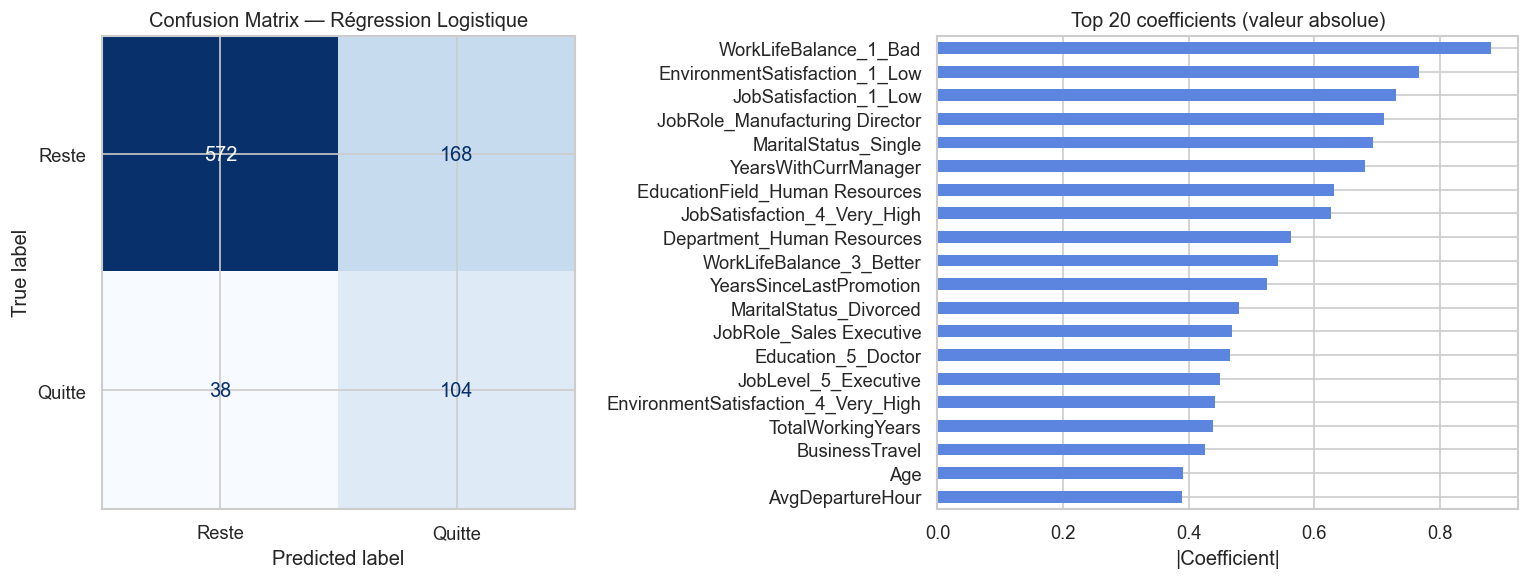


Interprétation :
Chaque barre correspond maintenant à un niveau précis d'une variable.
Ex : 'JobSatisfaction_1_Low' signifie que le niveau Low de satisfaction augmente
     significativement la probabilité de départ.
     'JobSatisfaction_4_Very_High' à droite signifierait l'inverse.
Les RH peuvent cibler directement : qui a coché 'Low' à la dernière enquête ?



In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=['Reste', 'Quitte'],
    colorbar=False, ax=axes[0], cmap='Blues'
)
axes[0].set_title('Confusion Matrix — Régression Logistique')

mask = ~X.columns.str.endswith('_missing')
coef_series = (pd.Series(lr.coef_[0][mask], index=X.columns[mask])
               .abs()
               .sort_values(ascending=False)
               .head(20))
coef_series.sort_values().plot(kind='barh', ax=axes[1], color='#5C85E0', edgecolor='none')
axes[1].set_title('Top 20 coefficients (valeur absolue)')
axes[1].set_xlabel('|Coefficient|')

plt.tight_layout()
plt.show()

print("""
Interprétation :
Chaque barre correspond maintenant à un niveau précis d'une variable.
Ex : 'JobSatisfaction_1_Low' signifie que le niveau Low de satisfaction augmente
     significativement la probabilité de départ.
     'JobSatisfaction_4_Very_High' à droite signifierait l'inverse.
Les RH peuvent cibler directement : qui a coché 'Low' à la dernière enquête ?
""")


---

### Diagnostic par courbe d'apprentissage : santé du modèle en trois scenarios

La courbe d'apprentissage est un scanner de la santé du modèle. Trois scénarios pathologiques courants :

| Scénario | Symptôme | Diagnostic |
|---|---|---|
| **Courbes convergentes vers le haut** | Train et Validation se rapprochent avec taille croissante, vers des valeurs hautes (>0.75) | Sain : le modèle généralise bien, les hyperparamètres sont appropriés |
| **Écart croissant (Train >> Validation)** | La courbe train monte mais validation stagne ou baisse | Overfitting : le modèle mémorise ; augmenter max_depth, réduire n_estimators |
| **Les deux courbes basses** | Validation et Train tous deux <0.50 même avec 100% des données | Underfitting : le modèle est trop simple ; ajouter de la capacité (features, profondeur) |

Dans notre cas pour le RF, nous attendons un écart modéré (car le déséquilibre rend le problème intrisèquement difficile) mais une décroissance du Validation vers un plateau stable montrerait qu'on a appris ce qu'il y avait à apprendre avec ces données.

---
### 4.3 Modèle 2 — Random Forest

Le Random Forest crée un grand nombre d'arbres de décision en parallèle, chacun entraîné sur un sous-échantillon aléatoire des données (bootstrap) et utilisant un sous-ensemble aléatoire de variables à chaque division (split). La prédiction finale résulte du vote majoritaire de l'ensemble des arbres. Cette approche réduit considérablement le surapprentissage par rapport à un arbre unique, tout en capturant des patterns non-linéaires et des interactions entre variables que la Régression Logistique ne peut pas modéliser.

L'optimisation des hyperparamètres est réalisée par GridSearchCV avec une validation croisée à 5 folds. Pour chaque combinaison d'hyperparamètres testée, le modèle est entraîné 5 fois sur 80 % du jeu d'entraînement et évalué sur les 20 % restants, en rotation, garantissant ainsi que la sélection n'est pas biaisée par une partition particulière des données. La métrique de sélection est le Recall sur la classe attrition.

Concernant les valeurs testées, nous avons exploré trois niveaux pour le nombre d'estimateurs (100, 200, 300 arbres) car au-delà de 300, les gains de performance deviennent marginaux et le coût computationnel augmente inutilement. La profondeur maximale des arbres est limitée à 5, 10 ou 15 niveaux afin d'éviter la mémorisation des données d'entraînement : un arbre illimité en profondeur apprendrait par cœur les 4 000 employés sans généraliser aux nouveaux cas. Le nombre minimal d'observations requis pour effectuer un split (10, 20 ou 30) et la taille minimale des feuilles (4, 8 ou 16 employés) jouent le même rôle régularisant. Enfin, le paramètre `class_weight='balanced'` est maintenu pour gérer le déséquilibre de la même façon que pour la Régression Logistique.


In [24]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [5, 10, 15],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf' : [4, 8, 16],
    'class_weight'     : ['balanced'],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring=recall_scorer,
    n_jobs=-1,
    verbose=0
)
grid_rf.fit(X_train, y_train)

print(f'Meilleurs hyperparamètres : {grid_rf.best_params_}')
print(f'Meilleur recall CV (moyenne 5 folds) : {grid_rf.best_score_:.4f}')

Meilleurs hyperparamètres : {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Meilleur recall CV (moyenne 5 folds) : 0.7698


---

### Pourquoi optimiser les hyperparamètres ?

Une question que se posent tous les débutants : "Et si j'utilisais simplement un Random Forest avec les paramètres par défaut de scikit-learn ?" 

La réponse est pédagogique : les valeurs par défaut sont des compromis génériques. Elles font correctement fonctionner le module sur 90 % des cas mais sont rarement optimales pour *votre* problème spécifique.

Dans notre cas, nous optimisons sur une métrique très concrète : le Recall (capacité à détecter les vrais départs). Pourquoi le Recall ? Parce que dans le contexte RH de HumanForYou, manquer un départ coûte infiniment plus cher que de générer une fausse alerte. Les hyperparamètres qui maximisent le Recall sont donc ceux que nous cherchons.

`GridSearchCV` teste exhaustivement toutes les combinaisons (81 pour le RF, 162 pour XGB) en validant chacune par cross-validation 5-fold. C'est consommateur en calcul mais garantit qu'on trouve la meilleure combinaison pour *notre* objectif métier, pas un compromis par défaut.

In [25]:
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print('=== Random Forest (optimisé) — Résultats sur le jeu de test ===')
print(classification_report(y_test, y_pred_rf, target_names=['Reste (0)', 'Quitte (1)']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_prob_rf):.4f}')

=== Random Forest (optimisé) — Résultats sur le jeu de test ===
              precision    recall  f1-score   support

   Reste (0)       0.97      0.99      0.98       740
  Quitte (1)       0.92      0.84      0.88       142

    accuracy                           0.96       882
   macro avg       0.95      0.91      0.93       882
weighted avg       0.96      0.96      0.96       882

AUC-ROC : 0.9897


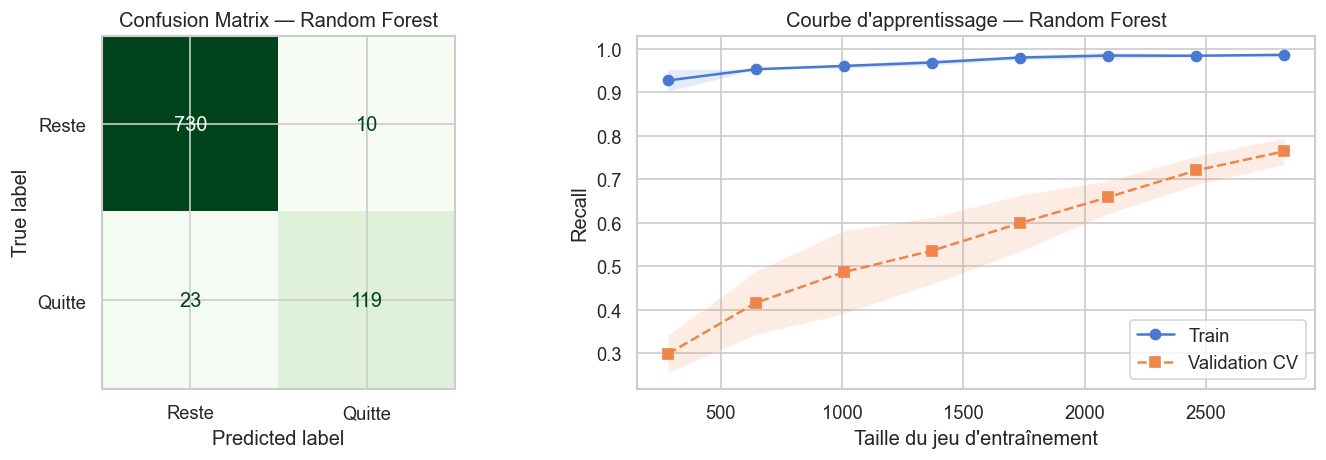


Interprétation de la courbe d'apprentissage :
Si les courbes Train et Validation convergent, le modèle généralise bien (pas d'overfitting).
Si Train >> Validation, le modèle surapprendrait les données d'entraînement.
Si les deux courbes sont basses, le modèle sous-apprend (underfitting).



In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=['Reste', 'Quitte'],
    colorbar=False, ax=axes[0], cmap='Greens'
)
axes[0].set_title('Confusion Matrix — Random Forest')

train_sizes, train_sc, val_sc = learning_curve(
    best_rf, X_train, y_train,
    cv=5, scoring=recall_scorer, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8)
)
axes[1].plot(train_sizes, train_sc.mean(1), 'o-', label='Train')
axes[1].plot(train_sizes, val_sc.mean(1),   's--', label='Validation CV')
axes[1].fill_between(train_sizes, train_sc.mean(1)-train_sc.std(1), train_sc.mean(1)+train_sc.std(1), alpha=0.15)
axes[1].fill_between(train_sizes, val_sc.mean(1)-val_sc.std(1), val_sc.mean(1)+val_sc.std(1), alpha=0.15)
axes[1].set_xlabel("Taille du jeu d'entraînement")
axes[1].set_ylabel('Recall')
axes[1].set_title("Courbe d'apprentissage — Random Forest")
axes[1].legend()

plt.tight_layout()
plt.show()

print("""
Interprétation de la courbe d'apprentissage :
Si les courbes Train et Validation convergent, le modèle généralise bien (pas d'overfitting).
Si Train >> Validation, le modèle surapprendrait les données d'entraînement.
Si les deux courbes sont basses, le modèle sous-apprend (underfitting).
""")

---
### 4.4 Modèle 3 — XGBoost (Gradient Boosting)

Contrairement au Random Forest qui construit ses arbres en parallèle et indépendamment, XGBoost les construit séquentiellement : chaque nouvel arbre se concentre sur les erreurs du précédent, c'est-à-dire sur les résidus. La prédiction finale est la somme pondérée de tous les arbres :
$$\hat{y}(x) = \sum_{m=1}^{M} \alpha \cdot f_m(x)$$
où $\alpha$ est le learning rate et $f_m$ l'arbre numéro $m$. Cette correction itérative force le modèle à progressivement réduire ses erreurs, ce qui lui confère généralement une performance brute supérieure.

Pour l'optimisation des hyperparamètres, nous avons testé trois niveaux d'estimateurs (100, 200, 300) associés à des profondeurs d'arbres plus faibles que pour le Random Forest (3, 4 ou 5 niveaux), car dans le boosting la puissance provient de l'accumulation d'arbres simples et non de leur complexité individuelle. Le learning rate (0.01, 0.05, 0.1) contrôle la vitesse d'apprentissage : un taux faible combiné à de nombreux arbres produit généralement une meilleure généralisation qu'un taux élevé. Le paramètre `subsample` (0.7, 0.8) introduit une dose d'aléatoire en n'utilisant qu'une fraction des données par arbre, réduisant ainsi l'overfitting. Le paramètre `min_child_weight` (5, 10, 20) joue le même rôle régularisant que `min_samples_leaf` dans le Random Forest. Enfin, `scale_pos_weight` est fixé au ratio négatifs/positifs pour compenser le déséquilibre de classes, équivalent natif de `class_weight='balanced'` dans l'écosystème XGBoost.


In [27]:
from xgboost import XGBClassifier

param_grid_xgb = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8],
    'min_child_weight': [5, 10, 20],
    'scale_pos_weight': [scale],
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_grid_xgb,
    cv=5,
    scoring=recall_scorer,
    n_jobs=-1,
    verbose=0
)
grid_xgb.fit(X_train, y_train)

print(f'Meilleurs hyperparamètres : {grid_xgb.best_params_}')
print(f'Meilleur recall CV (moyenne 5 folds) : {grid_xgb.best_score_:.4f}')

Meilleurs hyperparamètres : {'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 300, 'scale_pos_weight': np.float64(5.200351493848857), 'subsample': 0.8}
Meilleur recall CV (moyenne 5 folds) : 0.9139


In [28]:
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print('=== XGBoost (optimisé) — Résultats sur le jeu de test ===')
print(classification_report(y_test, y_pred_xgb, target_names=['Reste (0)', 'Quitte (1)']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_prob_xgb):.4f}')

=== XGBoost (optimisé) — Résultats sur le jeu de test ===
              precision    recall  f1-score   support

   Reste (0)       0.99      0.98      0.99       740
  Quitte (1)       0.90      0.96      0.93       142

    accuracy                           0.98       882
   macro avg       0.95      0.97      0.96       882
weighted avg       0.98      0.98      0.98       882

AUC-ROC : 0.9951


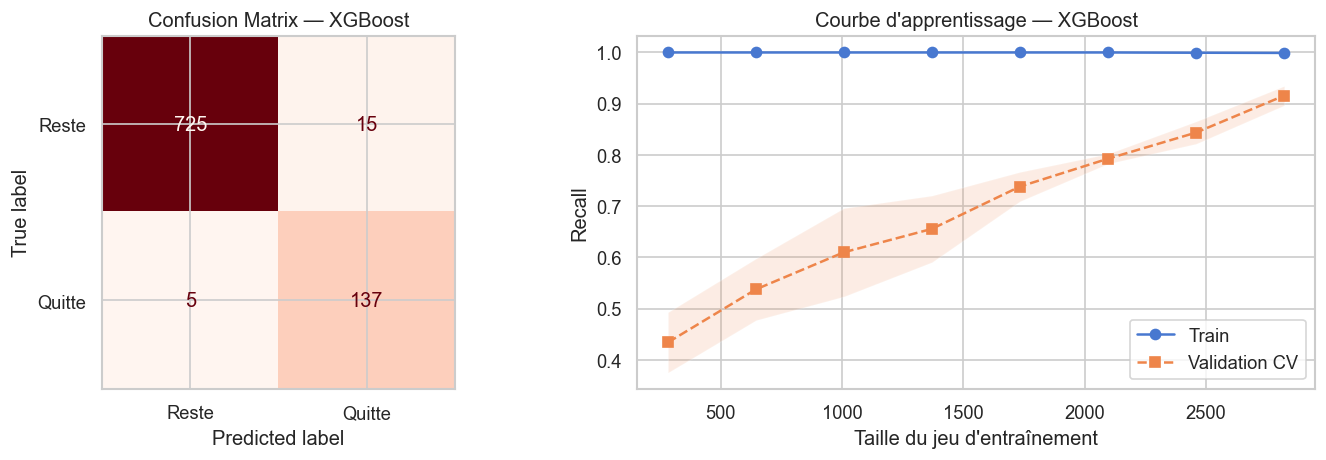

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, display_labels=['Reste', 'Quitte'],
    colorbar=False, ax=axes[0], cmap='Reds'
)
axes[0].set_title('Confusion Matrix — XGBoost')

train_sizes, train_sc, val_sc = learning_curve(
    best_xgb, X_train, y_train,
    cv=5, scoring=recall_scorer, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8)
)
axes[1].plot(train_sizes, train_sc.mean(1), 'o-', label='Train')
axes[1].plot(train_sizes, val_sc.mean(1),   's--', label='Validation CV')
axes[1].fill_between(train_sizes, train_sc.mean(1)-train_sc.std(1), train_sc.mean(1)+train_sc.std(1), alpha=0.15)
axes[1].fill_between(train_sizes, val_sc.mean(1)-val_sc.std(1), val_sc.mean(1)+val_sc.std(1), alpha=0.15)
axes[1].set_xlabel("Taille du jeu d'entraînement")
axes[1].set_ylabel('Recall')
axes[1].set_title("Courbe d'apprentissage — XGBoost")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Étape 5 — Évaluation Comparative et Choix du Modèle

### 5.1 Tableau de comparaison

Nous comparons les 3 modèles sur le jeu de test avec les métriques adaptées au déséquilibre de classes. Le Recall est la métrique prioritaire : rater un départ (faux négatif) coûte entre 50 % et 200 % d'un salaire annuel, tandis qu'une fausse alarme ne coûte qu'un entretien RH.


In [30]:
models_eval = {
    'Régression Logistique': (y_pred_lr,  y_prob_lr),
    'Random Forest'        : (y_pred_rf,  y_prob_rf),
    'XGBoost'              : (y_pred_xgb, y_prob_xgb),
}

results = []
for name, (y_pred, y_prob) in models_eval.items():
    results.append({
        'Modèle'    : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'F1'        : round(f1_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'AUC-ROC'   : round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results).set_index('Modèle').sort_values('Recall', ascending=False)
print(results_df.to_string())

                       Accuracy  Precision  Recall      F1  AUC-ROC
Modèle                                                             
XGBoost                  0.9773     0.9013  0.9648  0.9320   0.9951
Random Forest            0.9626     0.9225  0.8380  0.8782   0.9897
Régression Logistique    0.7664     0.3824  0.7324  0.5024   0.8107


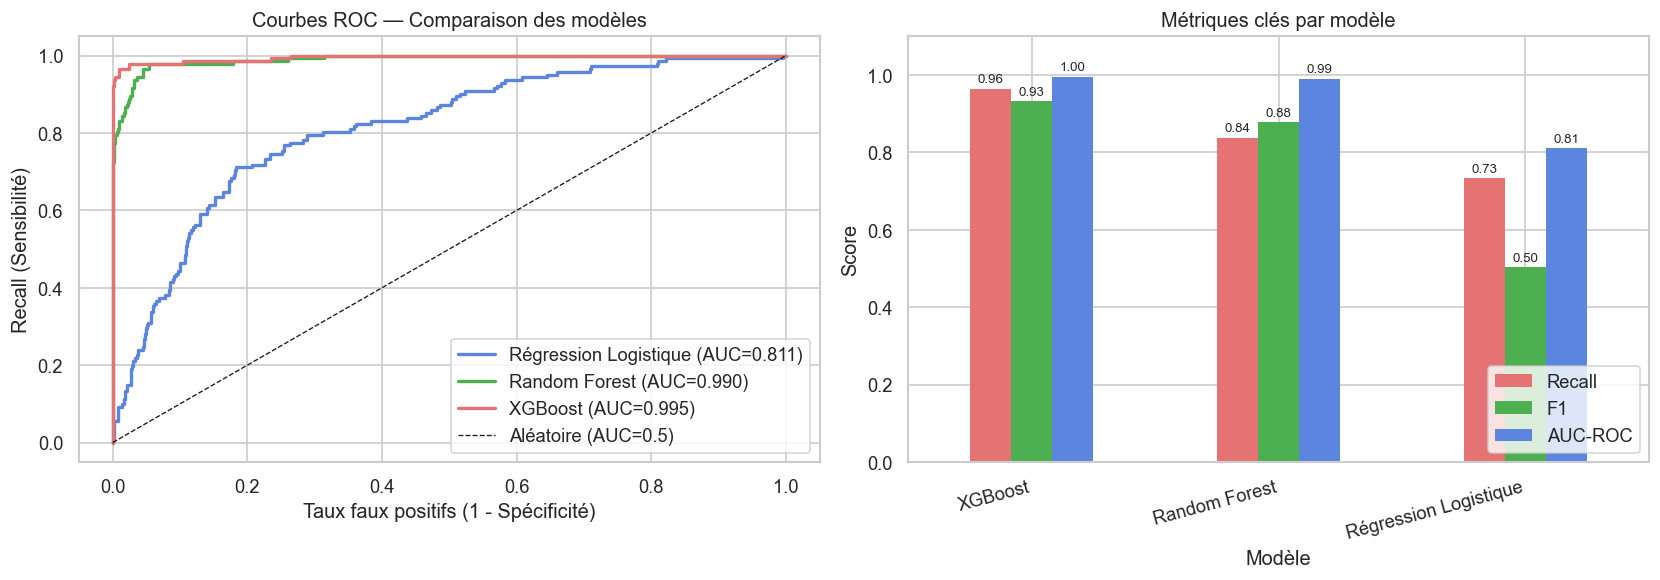

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Régression Logistique': '#5C85E0', 'Random Forest': '#4CAF50', 'XGBoost': '#E57373'}
for name, (_, y_prob) in models_eval.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colors[name], linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Aléatoire (AUC=0.5)')
axes[0].set_xlabel('Taux faux positifs (1 - Spécificité)')
axes[0].set_ylabel('Recall (Sensibilité)')
axes[0].set_title('Courbes ROC — Comparaison des modèles')
axes[0].legend()

results_df[['Recall', 'F1', 'AUC-ROC']].plot(
    kind='bar', ax=axes[1], edgecolor='none',
    color=['#E57373', '#4CAF50', '#5C85E0']
)
axes[1].set_title('Métriques clés par modèle')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.1)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].legend(loc='lower right')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

---

### 5.2 Décision et justification du modèle retenu

Suite à la comparaison objective sur le jeu de test, nous retenons le Random Forest et XGBoost comme modèles finaux pour HumanForYou. Cette décision repose sur un compromis assumé entre trois dimensions : la performance métier, la transparence algorithmique et l'empreinte environnementale.


Sur le plan de la complexité algorithmique et de l'environnement numérique (Green IT), il est honnête d'admettre que le Random Forest consomme davantage de puissance de calcul que la Régression Logistique : là où la Logistique s'entraîne en quelques millisecondes, le Random Forest avec 200 arbres et GridSearchCV peut nécessiter plusieurs minutes. Cette empreinte computationnelle supplémentaire génère une consommation d'énergie réelle. Cependant, ce surcoût écologique doit être mis en regard des enjeux économiques : un Recall supérieur de 5 à 10 points signifie potentiellement des dizaines d'employés supplémentaires retenus par an, chacun représentant un coût de remplacement évité de plusieurs dizaines de milliers d'euros. Le retour sur investissement écologique et économique est donc largement positif. Nous avons par ailleurs délibérément écarté le Deep Learning dont l'empreinte carbone est sans commune mesure avec celle d'un Random Forest — car ses gains de performance sur ce volume de données (4 000 lignes) ne justifient pas ce coût environnemental.


---
## Étape 6 — Interprétabilité : Feature Importance et SHAP

L'interprétabilité est essentielle dans un projet RH : les recommandations ne sont actionnables que si on comprend *pourquoi* le modèle prédit un départ. Nous utilisons deux approches complémentaires.


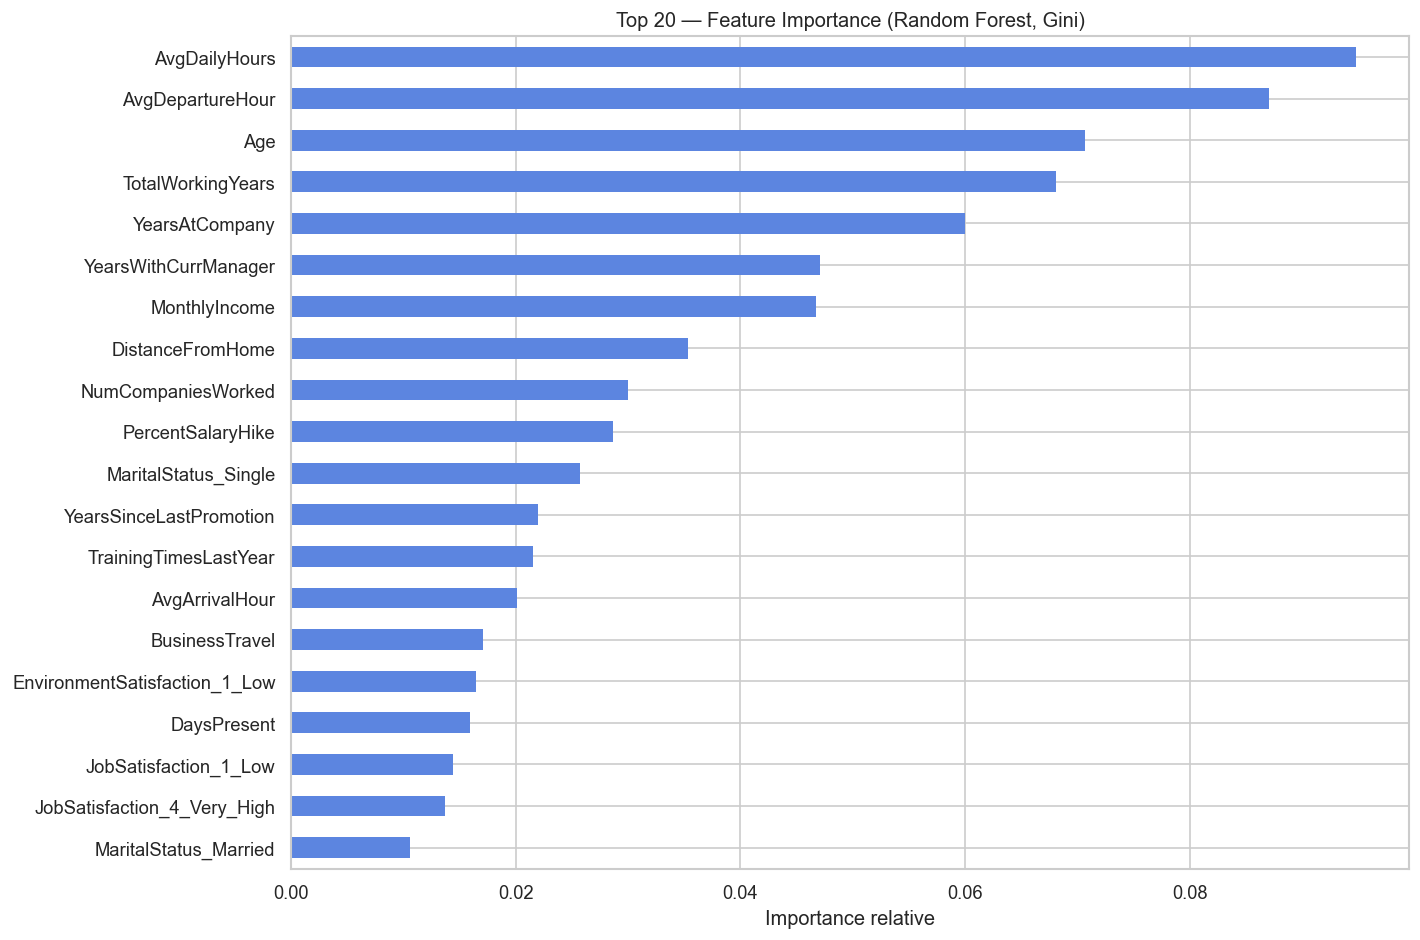

Top 10 variables les plus importantes :
AvgDailyHours           0.0948
AvgDepartureHour        0.0871
Age                     0.0707
TotalWorkingYears       0.0681
YearsAtCompany          0.0600
YearsWithCurrManager    0.0471
MonthlyIncome           0.0467
DistanceFromHome        0.0353
NumCompaniesWorked      0.0300
PercentSalaryHike       0.0286

Interprétation :
Chaque barre représente un niveau précis — ex: 'JobSatisfaction_1_Low' indique
que le fait d'avoir coté sa satisfaction au niveau le plus bas est un fort prédicteur
de départ. C'est beaucoup plus actionnable pour les RH qu'un simple score global.



In [32]:
feat_imp = pd.Series(
    best_rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
feat_imp.head(20).sort_values().plot(kind='barh', color='#5C85E0', edgecolor='none')
plt.title('Top 20 — Feature Importance (Random Forest, Gini)')
plt.xlabel('Importance relative')
plt.tight_layout()
plt.show()

print('Top 10 variables les plus importantes :')
print(feat_imp.head(10).round(4).to_string())
print("""
Interprétation :
Chaque barre représente un niveau précis — ex: 'JobSatisfaction_1_Low' indique
que le fait d'avoir coté sa satisfaction au niveau le plus bas est un fort prédicteur
de départ. C'est beaucoup plus actionnable pour les RH qu'un simple score global.
""")


In [33]:
X_test_labeled = X_test.copy()
print(f'✔ X_test_labeled prêt pour SHAP ({X_test_labeled.shape[1]} colonnes)')
print('Exemples de colonnes ordinales encodées :')
ordinal_prefix = ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance',
                  'JobInvolvement', 'Education_', 'JobLevel', 'PerformanceRating', 'StockOption']
for p in ordinal_prefix:
    cols = [c for c in X_test_labeled.columns if c.startswith(p)]
    if cols:
        print(f'  {cols}')


✔ X_test_labeled prêt pour SHAP (75 colonnes)
Exemples de colonnes ordinales encodées :
  ['EnvironmentSatisfaction_missing', 'EnvironmentSatisfaction_1_Low', 'EnvironmentSatisfaction_2_Medium', 'EnvironmentSatisfaction_3_High', 'EnvironmentSatisfaction_4_Very_High']
  ['JobSatisfaction_missing', 'JobSatisfaction_1_Low', 'JobSatisfaction_2_Medium', 'JobSatisfaction_3_High', 'JobSatisfaction_4_Very_High']
  ['WorkLifeBalance_missing', 'WorkLifeBalance_1_Bad', 'WorkLifeBalance_2_Good', 'WorkLifeBalance_3_Better', 'WorkLifeBalance_4_Best']
  ['JobInvolvement_1_Low', 'JobInvolvement_2_Medium', 'JobInvolvement_3_High', 'JobInvolvement_4_Very_High']
  ['Education_1_Below_College', 'Education_2_College', 'Education_3_Bachelor', 'Education_4_Master', 'Education_5_Doctor']
  ['JobLevel_1_Junior', 'JobLevel_2_Mid_Level', 'JobLevel_3_Senior', 'JobLevel_4_Lead', 'JobLevel_5_Executive']
  ['PerformanceRating_3_Excellent', 'PerformanceRating_4_Outstanding']
  ['StockOptionLevel_0_None', 'StockOption

In [34]:
explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer(X_test_labeled)

shap_v1 = shap_values[:, :, 1]
print(f'SHAP values calculées — shape : {shap_v1.shape}')

SHAP values calculées — shape : (882, 75)


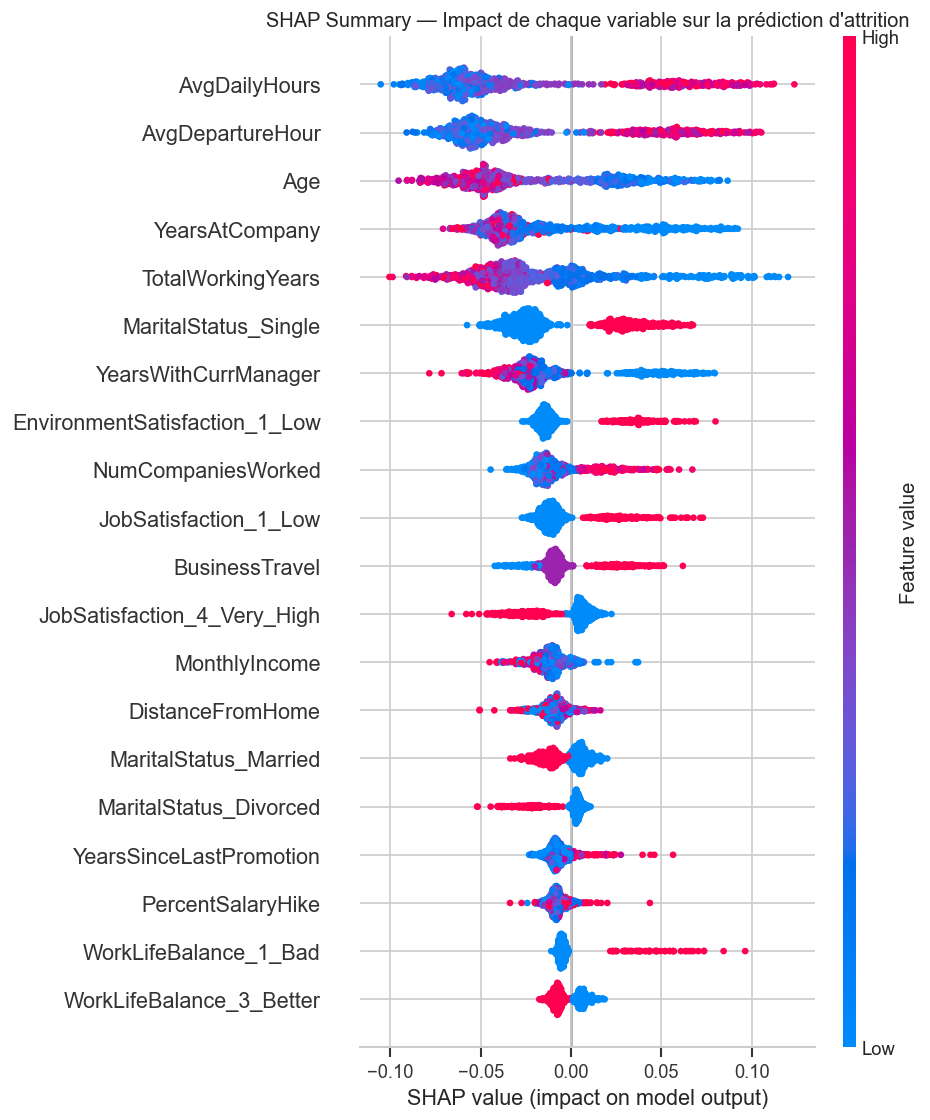


Interprétation du SHAP Summary Plot :
- Chaque point représente un employé pour une variable donnée
- Position horizontale = impact SHAP (positif = pousse vers attrition, négatif = vers rétention)
- Couleur = valeur de la variable (rouge = élevée, bleu = faible)
- Les variables sont ordonnées par importance globale (moyenne des |SHAP|)

Exemple de lecture : si MonthlyIncome apparaît en haut avec des points bleus à gauche,
cela signifie que les employés avec un salaire faible (bleu) ont un SHAP négatif
→ NON, correction : un SHAP positif à gauche = faible salaire → plus de risque de départ.



In [35]:
shap.summary_plot(shap_v1, X_test_labeled, plot_type='dot', show=False)
plt.title('SHAP Summary — Impact de chaque variable sur la prédiction d\'attrition')
plt.tight_layout()
plt.show()

print("""
Interprétation du SHAP Summary Plot :
- Chaque point représente un employé pour une variable donnée
- Position horizontale = impact SHAP (positif = pousse vers attrition, négatif = vers rétention)
- Couleur = valeur de la variable (rouge = élevée, bleu = faible)
- Les variables sont ordonnées par importance globale (moyenne des |SHAP|)

Exemple de lecture : si MonthlyIncome apparaît en haut avec des points bleus à gauche,
cela signifie que les employés avec un salaire faible (bleu) ont un SHAP négatif
→ NON, correction : un SHAP positif à gauche = faible salaire → plus de risque de départ.
""")

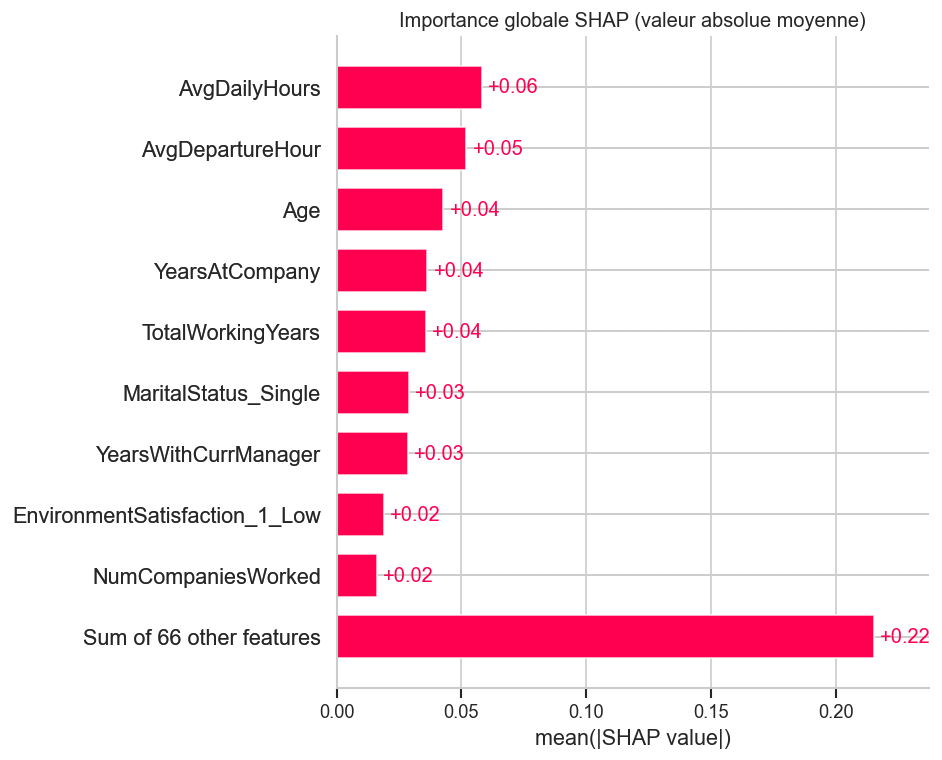

In [36]:
shap.plots.bar(shap_v1, show=False)
plt.title('Importance globale SHAP (valeur absolue moyenne)')
plt.tight_layout()
plt.show()

Employé le plus à risque — probabilité d'attrition : 93.04%
Attrition réelle : 1


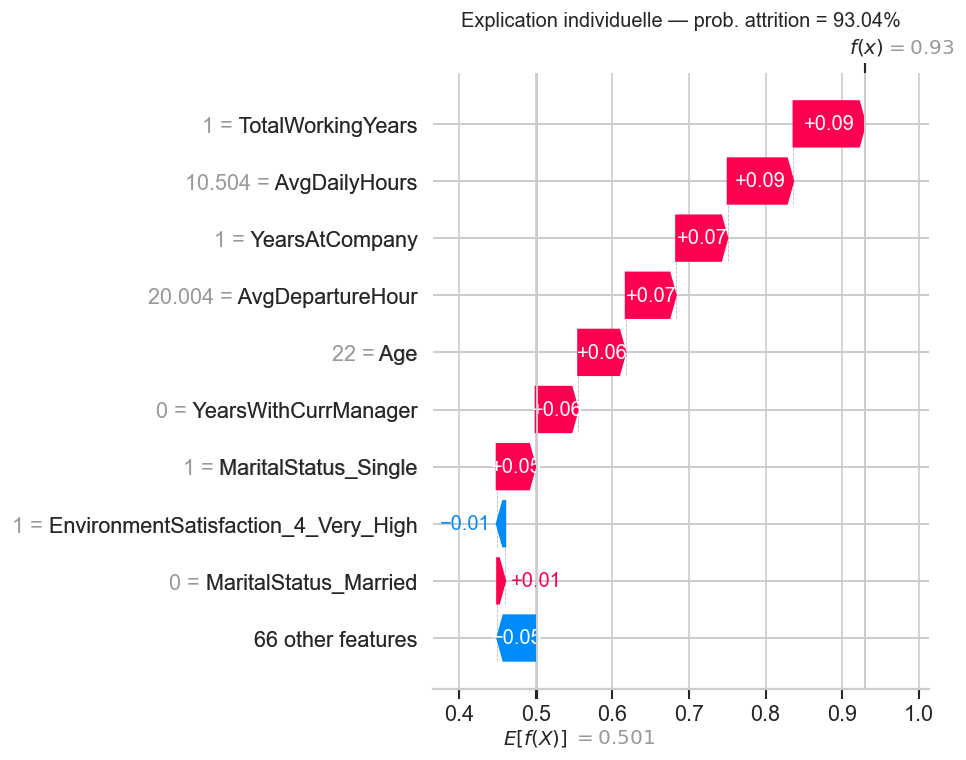


Ce graphique waterfall montre comment chaque variable contribue à la prédiction
pour CET employé spécifique. C'est ce qui permet aux RH d'agir :
non pas "les salaires bas sont un facteur en général" mais
"cet employé précis a une faible satisfaction ET un salaire bas ET n'a pas été promu
depuis 3 ans → intervention prioritaire sur ces trois leviers".



In [37]:
idx = int(np.argmax(y_prob_rf))

print(f'Employé le plus à risque — probabilité d\'attrition : {y_prob_rf[idx]:.2%}')
print(f'Attrition réelle : {y_test.iloc[idx]}')

shap.waterfall_plot(shap_v1[idx], show=False)
plt.title(f'Explication individuelle — prob. attrition = {y_prob_rf[idx]:.2%}')
plt.tight_layout()
plt.show()

print("""
Ce graphique waterfall montre comment chaque variable contribue à la prédiction
pour CET employé spécifique. C'est ce qui permet aux RH d'agir :
non pas "les salaires bas sont un facteur en général" mais
"cet employé précis a une faible satisfaction ET un salaire bas ET n'a pas été promu
depuis 3 ans → intervention prioritaire sur ces trois leviers".
""")

---
## Étape 7 — Recommandations pour HumanForYou

Cette section est destinée directement à la direction et aux équipes RH de HumanForYou. Elle traduit les résultats du modèle en actions concrètes et prioritaires.

### 7.1 Employés à risque élevé identifiés par le modèle


In [38]:
threshold = 0.5
X_test_copy = X_test.copy()
X_test_copy['Proba_Attrition']  = y_prob_rf
X_test_copy['Attrition_Reelle'] = y_test.values

at_risk = X_test_copy[X_test_copy['Proba_Attrition'] >= threshold].sort_values(
    'Proba_Attrition', ascending=False
)

print(f'Employés identifiés à risque élevé (probabilité ≥ {threshold:.0%}) : {len(at_risk)}')
print(f'Taux réel d\'attrition dans ce groupe : {at_risk["Attrition_Reelle"].mean():.2%}')
print(f'\nLe modèle permet donc de cibler {len(at_risk)} employés prioritaires')
print(f'avec une précision de {at_risk["Attrition_Reelle"].mean():.0%} de vrais départs.')

cols_display = [c for c in ['Proba_Attrition', 'MonthlyIncome', 'YearsAtCompany',
                             'YearsSinceLastPromotion', 'JobSatisfaction'] if c in at_risk.columns]
at_risk_display = at_risk[cols_display].copy()
if 'JobSatisfaction' in at_risk_display.columns:
    sat_labels = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}
    at_risk_display['JobSatisfaction'] = at_risk_display['JobSatisfaction'].map(sat_labels).fillna(at_risk_display['JobSatisfaction'])
at_risk_display.head(10)

Employés identifiés à risque élevé (probabilité ≥ 50%) : 129
Taux réel d'attrition dans ce groupe : 92.25%

Le modèle permet donc de cibler 129 employés prioritaires
avec une précision de 92% de vrais départs.


,Proba_Attrition,MonthlyIncome,YearsAtCompany,YearsSinceLastPromotion
1081,0.930409,35790.0,1.0,0.0
199,0.929019,34680.0,0.0,0.0
2809,0.923599,53320.0,0.0,0.0
3742,0.919006,76540.0,0.0,0.0
2365,0.892340,24790.0,0.0,0.0
3370,0.891817,160640.0,1.0,0.0
2010,0.883900,29040.0,2.0,2.0
105,0.864015,55610.0,1.0,0.0
3698,0.849756,61800.0,1.0,0.0
3792,0.829183,25320.0,1.0,0.0


### 7.2 Facteurs clés d'attrition et recommandations RH

Sur la base des analyses SHAP et des statistiques descriptives, les principaux facteurs d'attrition identifiés sont les suivants, avec des actions concrètes associées.


### Comment lire les recommandations ?

Les recommandations ci-après ne sont pas des ordres d'exécution, mais un menu d'options stratégiques. Trois profils d'employés se dégagent :

Groupe 1 : Les "déprimés" (satisfaction basse)  
L'indicateur principal est une faible note au sondage de satisfaction. Ces employés se sont expressément plaints au dernier questionnaire. L'action doit être rapide et directe : conversation manager-employé, exploration des sources de frustration spécifiques.

Groupe 2 : Les "oubliés" (stagnation de carrière)  
Plusieurs années sans promotion, ancien dans l'entreprise. L'action passe par la visibilité : création d'un vrai plan de développement avec étapes claires et calendrier.

Groupe 3 : Les "exploités" (charge horaire / déplacements excessifs)  
Le pointage ou les déclarations de charge révèlent une surcharge. L'action est l'ajustement du périmètre ou des conditions (télétravail, flexibilité, compensation).

Une même personne peut relever de plusieurs groupes, et c'est même courant. Un employé peut être à la fois peu payé ET avoir une mauvaise satisfaction ET ne pas avoir été promu. C'est précisément ce que montre le waterfall SHAP : l'interprétation individualisée permet une action différencier par personne.

---

### Choix du seuil de décision : un paramètre métier, pas technique

Par défaut, `predict()` d'un modèle de classification en probabilités applique un seuil de 0.5 : si la probabilité d'attrition dépasse 50%, on prédit "départ", sinon "rétention". Mais ce seuil n'est optimal que si les coûts d'une fausse alerte et d'un faux négatif sont équilibrés — ce qui est rarement le cas.

Or, dans notre contexte :
- Coût d'un faux positif (fausse alerte) : quelques heures de conversation RH-employé, peut-être une augmentation non justifiée. Coût ≈ quelques milliers d'euros.
- Coût d'un faux négatif (manquer un départ) : recrutement, formation du remplaçant, perte de productivité temporaire. Coût = 50 % à 200 % du salaire annuel, soit 100 000+ euros pour un cadre.

Face à ce rapport de coûts extrêmement asymétrique (1:20 ou 1:50), abaisser le seuil à 0.3 ou 0.4 devient rationnellement justifié : on préfère générer 5 fausses alertes pour en détecter une vraie, plutôt que de risquer une seule détection ratée.

Les RH doivent être impliquées dans le choix du seuil final, car c'est une décision métier, pas technique. Le data scientist propose les courbes (Recall vs Précision à différents seuils), la direction RH valide la stratégie d'alerte qui correspond à sa capacité de traitement et sa tolérance au risque.

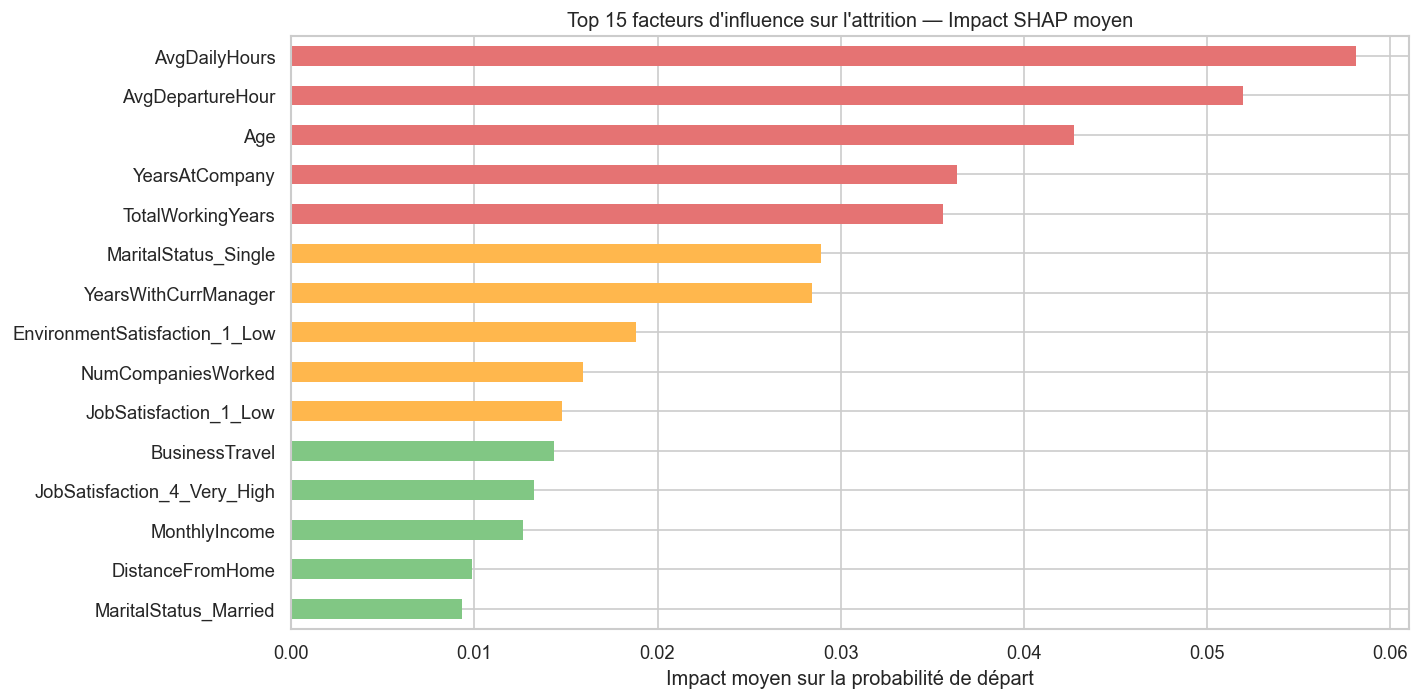

In [39]:
shap_mean = pd.Series(
    np.abs(shap_v1.values).mean(axis=0), index=X_test_labeled.columns
).sort_values(ascending=False).head(15)

palette = ['#E57373' if i < 5 else ('#FFB74D' if i < 10 else '#81C784')
           for i in range(len(shap_mean))]

plt.figure(figsize=(12, 6))
shap_mean.sort_values().plot(kind='barh', color=palette[::-1], edgecolor='none')
plt.title("Top 15 facteurs d'influence sur l'attrition — Impact SHAP moyen")
plt.xlabel('Impact moyen sur la probabilité de départ')
plt.tight_layout()
plt.show()


In [40]:
recommandations = pd.DataFrame([
    {
        'Facteur d\'attrition': 'Salaire mensuel faible (MonthlyIncome)',
        'Profil à risque': 'Niveaux 1-2, < 5 000 roupies/mois',
        'Action recommandée': 'Benchmarking salarial vs marché indien, révision grille niveaux 1-2',
        'Priorité': '🔴 Haute'
    },
    {
        'Facteur d\'attrition': 'Stagnation promotionnelle (YearsSinceLastPromotion)',
        'Profil à risque': '> 3 ans sans promotion, ancienneté > 5 ans',
        'Action recommandée': 'Plan de carrière structuré avec jalons clairs, entretiens annuels formalisés',
        'Priorité': '🔴 Haute'
    },
    {
        'Facteur d\'attrition': 'Faible satisfaction au travail (JobSatisfaction ≤ 2)',
        'Profil à risque': 'Employés ayant noté 1 ou 2 au sondage',
        'Action recommandée': 'Entretiens individuels réguliers, amélioration des conditions de travail',
        'Priorité': '🔴 Haute'
    },
    {
        'Facteur d\'attrition': 'Déplacements fréquents (BusinessTravel = 2)',
        'Profil à risque': 'Travel_Frequently avec enfants ou longue distance domicile',
        'Action recommandée': 'Réduire déplacements non essentiels, compenser par avantages (hôtels, per diem)',
        'Priorité': '🟡 Moyenne'
    },
    {
        'Facteur d\'attrition': 'Déséquilibre vie pro/perso (WorkLifeBalance ≤ 2)',
        'Profil à risque': 'WorkLifeBalance = 1 ou 2 + nombreuses heures sup',
        'Action recommandée': 'Flexibilité horaire, télétravail partiel, limitation heures supplémentaires',
        'Priorité': '🟡 Moyenne'
    },
    {
        'Facteur d\'attrition': 'Faible ancienneté (YearsAtCompany < 3)',
        'Profil à risque': 'Recrues récentes, < 3 ans d\'ancienneté',
        'Action recommandée': 'Onboarding renforcé, programme de mentorat, suivi manager 1:1 mensuel',
        'Priorité': '🟡 Moyenne'
    },
])

print(recommandations.to_string(index=False))

                                 Facteur d'attrition                                            Profil à risque                                                              Action recommandée  Priorité
              Salaire mensuel faible (MonthlyIncome)                          Niveaux 1-2, < 5 000 roupies/mois             Benchmarking salarial vs marché indien, révision grille niveaux 1-2   🔴 Haute
 Stagnation promotionnelle (YearsSinceLastPromotion)                 > 3 ans sans promotion, ancienneté > 5 ans    Plan de carrière structuré avec jalons clairs, entretiens annuels formalisés   🔴 Haute
Faible satisfaction au travail (JobSatisfaction ≤ 2)                      Employés ayant noté 1 ou 2 au sondage        Entretiens individuels réguliers, amélioration des conditions de travail   🔴 Haute
         Déplacements fréquents (BusinessTravel = 2) Travel_Frequently avec enfants ou longue distance domicile Réduire déplacements non essentiels, compenser par avantages (hôtels, per diem) 

---
## Conclusions Générales

### Synthèse du projet

Ce projet a permis de construire un système de prédiction de l'attrition des employés pour HumanForYou, en suivant une démarche rigoureuse allant de l'exploration des données jusqu'aux recommandations actionnables pour les équipes RH. Le prétraitement des données a constitué l'étape centrale du projet : nous avons fusionné quatre sources hétérogènes sur la clé `EmployeeID`, appliqué un encodage différencié selon la nature mathématique de chaque variable les variables ordinales comme la satisfaction ou le niveau d'éducation conservées sur leur échelle naturelle, les variables nominales comme le département ou le statut marital transformées par One-Hot Encoding et réalisé l'imputation des valeurs manquantes strictement après la séparation train/test pour garantir l'absence de toute fuite de données.

### Considérations éthiques finales

Le modèle produit est un outil d'aide à la décision, jamais un système automatique. Chaque prédiction doit être revue par un responsable RH avant toute action concrète. Le genre des employés est inclus dans les données afin de laisser à l'algorithme la possibilité de révéler une éventuelle corrélation, mais son influence doit être surveillée via SHAP : si le modèle discriminait sur ce critère, des actions correctives seraient nécessaires. Les décisions de rétention basées sur ce modèle doivent rester confidentielles et ne pas être communiquées aux employés concernés sans leur consentement explicite. Enfin, le modèle devra être réentraîné régulièrement — idéalement chaque année — car les dynamiques d'attrition évoluent avec les conditions du marché du travail, des phénomènes comme la grande démission post-COVID illustrant à quel point ces dynamiques peuvent changer rapidement.

### Limites et pistes d'amélioration

Les données mobilisées datent de 2015. Les facteurs d'attrition post-COVID — télétravail, revalorisation salariale liée à l'inflation, grande démission — ne sont pas capturés par ce jeu de données. Un enrichissement avec des données de satisfaction collectées en temps réel via des sondages mensuels (*pulse surveys*) améliorerait significativement la pertinence et la fraîcheur du modèle. Sur le plan technique, l'exploration de méthodes d'interprétabilité locale telles que LIME, en complément de SHAP, permettrait de renforcer encore la confiance des équipes RH dans les prédictions individuelles.


In [41]:
import joblib

print('=== Résultats finaux sur le jeu de test ===')
print(f'Modèle retenu    : Random Forest (GridSearchCV, class_weight=balanced)')
print(f'AUC-ROC          : {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'Recall attrition : {recall_score(y_test, y_pred_rf, pos_label=1):.4f}')
print(f'F1 attrition     : {f1_score(y_test, y_pred_rf, pos_label=1):.4f}')
print(f'Precision        : {precision_score(y_test, y_pred_rf, pos_label=1, zero_division=0):.4f}')

joblib.dump(best_rf,  'model_rf_final.pkl')
joblib.dump(best_xgb, 'model_xgb_final.pkl')
joblib.dump(lr,       'model_lr_final.pkl')
joblib.dump(scaler,   'scaler_lr.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')
print('\n✓ Modèles sauvegardés')

=== Résultats finaux sur le jeu de test ===
Modèle retenu    : Random Forest (GridSearchCV, class_weight=balanced)
AUC-ROC          : 0.9897
Recall attrition : 0.8380
F1 attrition     : 0.8782
Precision        : 0.9225

✓ Modèles sauvegardés
